## Setup

In [ ]:
import logging
import sys

sys.path.append('../')

from protac_degradation_predictor.data.datasets import MolPoiE3CellDataset

# Setup logging level
logging.basicConfig(level=logging.INFO)

In [ ]:
from lightning_uq_box.viz_utils import (
    plot_calibration_uq_toolbox,
    plot_predictions_regression,
    plot_toy_regression_data,
    plot_training_metrics,
)
from lightning_uq_box.uq_methods.loss_functions import DERLoss
from lightning_uq_box.uq_methods.deep_evidential_regression import DERLayer

In [ ]:
import pytorch_lightning as pl
import torch

pl.seed_everything(42)
torch.set_default_dtype(torch.float32)

## Prepare Data

In [1040]:
from datasets import load_dataset

# Load the dataset from HuggingFace Hub
dataset = load_dataset("ailab-bio/PROTAC-Degradation-Predictor-Dataset")

dataset

DatasetDict({
    train: Dataset({
        features: ['Smiles', 'POI Sequence', 'E3 Ligase Sequence', 'Cell Type', 'Uniprot', 'POI Cluster', 'E3 Ligase', 'Dmax (%) (DC50/Dmax)', 'pDC50 (DC50/Dmax)', 'pIC50 (Cellular activities, IC50)', 'pIC50 (Protac to Target, IC50)'],
        num_rows: 5248
    })
    validation: Dataset({
        features: ['Smiles', 'POI Sequence', 'E3 Ligase Sequence', 'Cell Type', 'Uniprot', 'POI Cluster', 'E3 Ligase', 'Dmax (%) (DC50/Dmax)', 'pDC50 (DC50/Dmax)', 'pIC50 (Cellular activities, IC50)', 'pIC50 (Protac to Target, IC50)'],
        num_rows: 542
    })
    test: Dataset({
        features: ['Smiles', 'POI Sequence', 'E3 Ligase Sequence', 'Cell Type', 'Uniprot', 'POI Cluster', 'E3 Ligase', 'Dmax (%) (DC50/Dmax)', 'pDC50 (DC50/Dmax)', 'pIC50 (Cellular activities, IC50)', 'pIC50 (Protac to Target, IC50)'],
        num_rows: 921
    })
})

Train size: 5,248
  Dmax (%) (DC50/Dmax): 1,153 (22.0%)
  pDC50 (DC50/Dmax): 1,586 (30.2%)
  pIC50 (Cellular activities, IC50): 2,822 (53.8%)
  pIC50 (Protac to Target, IC50): 1,131 (21.6%)


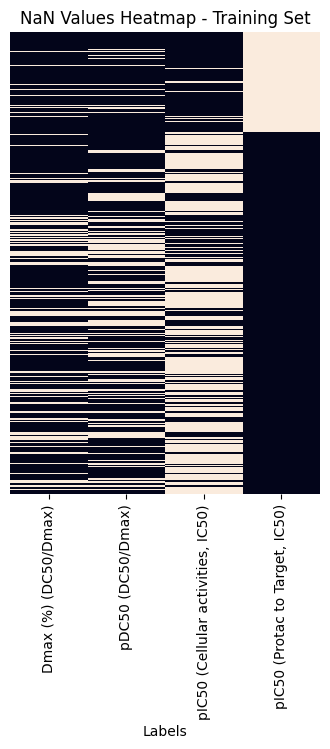

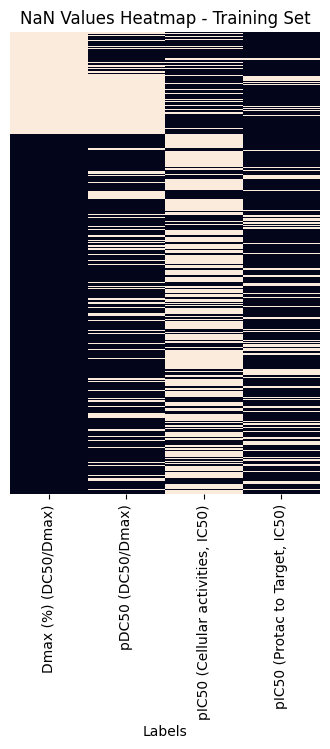

In [1050]:
label_columns = [
    "Dmax (%) (DC50/Dmax)",
    "pDC50 (DC50/Dmax)",
    "pIC50 (Cellular activities, IC50)",
    "pIC50 (Protac to Target, IC50)",
]

train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

print(f"Train size: {len(train_df):,}")
# For each label, print number of non-null values and the percentage w.r.t. the total number of samples
for label in label_columns:
    n_non_null = train_df[label].notnull().sum()
    pct_non_null = n_non_null / len(train_df) * 100
    print(f"  {label}: {n_non_null:,} ({pct_non_null:.1f}%)")

# Plot the nan values heatmap for the training set
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4, 6))
sns.heatmap(train_df[label_columns].sort_values(by=label_columns[-1]).notnull(), cbar=False, yticklabels=False)
plt.title("NaN Values Heatmap - Training Set")
plt.xlabel("Labels")
plt.show()

plt.figure(figsize=(4, 6))
sns.heatmap(train_df[label_columns].sort_values(by=label_columns[0]).notnull(), cbar=False, yticklabels=False)
plt.title("NaN Values Heatmap - Training Set")
plt.xlabel("Labels")
plt.show()

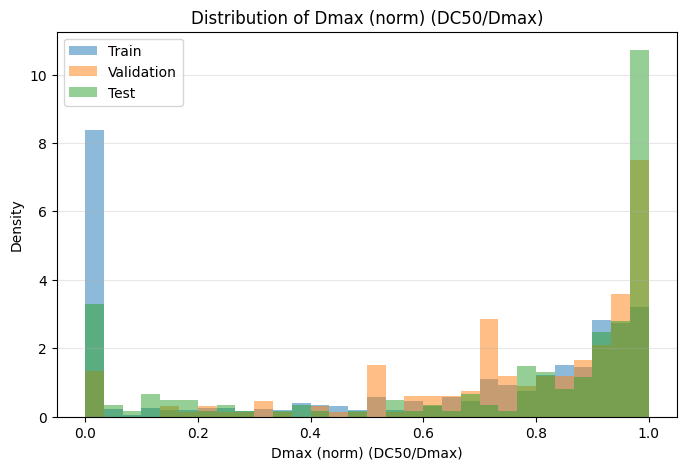

In [1051]:
from protac_degradation_predictor.data.utils import dmax_forward
import pandas as pd

train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

# # Concate all dataframes and then randomly split them again 80/10/10
# all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
# all_df = all_df.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle the dataframe
# train_size = int(0.8 * len(all_df))
# val_size = int(0.1 * len(all_df))
# train_df = all_df.iloc[:train_size]
# val_df = all_df.iloc[train_size:train_size + val_size]
# test_df = all_df.iloc[train_size + val_size:]

for df in [train_df, val_df, test_df]:
    df['Dmax (norm) (DC50/Dmax)'] = df['Dmax (%) (DC50/Dmax)'].apply(dmax_forward)
    df['Dmax (%) (DC50/Dmax)'] = df['Dmax (%) (DC50/Dmax)'] / 100
    # df['Dmax (norm) (DC50/Dmax)'] = df['Dmax (norm) (DC50/Dmax)'].apply(lambda x: x / 10)
    # Scale other labels by a factor of 10
    df["pDC50 (DC50/Dmax)"] = df["pDC50 (DC50/Dmax)"].apply(lambda x: x / 10)
    df["pIC50 (Cellular activities, IC50)"] = df["pIC50 (Cellular activities, IC50)"].apply(lambda x: x / 10)
    df["pIC50 (Protac to Target, IC50)"] = df["pIC50 (Protac to Target, IC50)"].apply(lambda x: x / 10)

label_columns = [
    "Dmax (%) (DC50/Dmax)",
    "pDC50 (DC50/Dmax)",
    "pIC50 (Cellular activities, IC50)",
    "pIC50 (Protac to Target, IC50)",
]

# Plot the distributions of the Dmax (norm) label
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(train_df[label_columns[0]], bins=30, alpha=0.5, label='Train', color='C0', density=True)
plt.hist(val_df[label_columns[0]], bins=30, alpha=0.5, label='Validation', color='C1', density=True)
plt.hist(test_df[label_columns[0]], bins=30, alpha=0.5, label='Test', color='C2', density=True)
plt.xlabel('Dmax (norm) (DC50/Dmax)')
plt.ylabel('Density')
plt.title('Distribution of Dmax (norm) (DC50/Dmax)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [1084]:
# Setup logging level
logging.basicConfig(level=logging.DEBUG)

datasets = {}
for split, df in zip(["train", "val", "test"], [train_df, val_df, test_df]):
    print('-' * 80)
    print(f"Processing {split} dataset with {len(df)} samples.")
    print('-' * 80)
    datasets[split] = MolPoiE3CellDataset(
        df=df,
        mol_column="Smiles",
        poi_column="POI Sequence",
        e3_column="E3 Ligase Sequence",
        cell_column="Cell Type",
        label_columns=label_columns,
        mol_embeddings_kwargs={
            # "embeddings_type": "fingerprint", 
            # "radius": 3,
            # "fp_size": 2048,
            "embeddings_type": "transformer",
            "pretrained_model": "ailab-bio/PROTAC-Splitter-Encoder",
            "load_from_cache": True,
        },
        protein_embeddings_kwargs={
            # "embeddings_type": "amino_acid_count",
            # "count_vect_kwargs": {
            #     "ngram_range": (1, 3),
            #     "analyzer": "char_wb",
            #     "vocabulary": list("ARNDCQEGHILKMFPSTWYVBZX*"),
            #     "lowercase": False,
            # }
            "embeddings_type": "esm",
            "batch_size": 2,
            "load_from_cache": True,
        },
        cell_embeddings_kwargs={
            # "embeddings_type": "one_hot",
            # "onehot_enc_kwargs": {},
            "embeddings_type": "sentence_transformer",
            "load_from_cache": True,
        },
        imputer="iterative" if split == "train" else None,
        imputer_kwargs={} if split == "train" else None,
        save_embeddings_to_cache=True, #  if split == "train" else False,
    )

# Setup logging level
logging.basicConfig(level=logging.INFO)

--------------------------------------------------------------------------------
Processing train dataset with 5248 samples.
--------------------------------------------------------------------------------


INFO:root:Embeddings loaded from /Users/ribes/.cache/protac_degradation_predictor/mol_embeddings_transformer.npz
INFO:root:Embeddings loaded from /Users/ribes/.cache/protac_degradation_predictor/protein_embeddings_esm.npz
INFO:root:Embeddings loaded from /Users/ribes/.cache/protac_degradation_predictor/cell_embeddings_sentence_transformer.npz
INFO:root:Embeddings saved to /Users/ribes/.cache/protac_degradation_predictor/mol_embeddings_transformer.npz
INFO:root:Embeddings saved to /Users/ribes/.cache/protac_degradation_predictor/protein_embeddings_esm.npz
INFO:root:Embeddings saved to /Users/ribes/.cache/protac_degradation_predictor/cell_embeddings_sentence_transformer.npz


--------------------------------------------------------------------------------
Processing val dataset with 542 samples.
--------------------------------------------------------------------------------


INFO:root:Embeddings loaded from /Users/ribes/.cache/protac_degradation_predictor/mol_embeddings_transformer.npz
INFO:root:Embeddings loaded from /Users/ribes/.cache/protac_degradation_predictor/protein_embeddings_esm.npz
INFO:root:Embeddings loaded from /Users/ribes/.cache/protac_degradation_predictor/cell_embeddings_sentence_transformer.npz
INFO:root:Embeddings saved to /Users/ribes/.cache/protac_degradation_predictor/mol_embeddings_transformer.npz
INFO:root:Embeddings saved to /Users/ribes/.cache/protac_degradation_predictor/protein_embeddings_esm.npz
INFO:root:Embeddings saved to /Users/ribes/.cache/protac_degradation_predictor/cell_embeddings_sentence_transformer.npz


--------------------------------------------------------------------------------
Processing test dataset with 921 samples.
--------------------------------------------------------------------------------


INFO:root:Embeddings loaded from /Users/ribes/.cache/protac_degradation_predictor/mol_embeddings_transformer.npz
INFO:root:Embeddings loaded from /Users/ribes/.cache/protac_degradation_predictor/protein_embeddings_esm.npz
INFO:root:Embeddings loaded from /Users/ribes/.cache/protac_degradation_predictor/cell_embeddings_sentence_transformer.npz
INFO:root:Embeddings saved to /Users/ribes/.cache/protac_degradation_predictor/mol_embeddings_transformer.npz
INFO:root:Embeddings saved to /Users/ribes/.cache/protac_degradation_predictor/protein_embeddings_esm.npz
INFO:root:Embeddings saved to /Users/ribes/.cache/protac_degradation_predictor/cell_embeddings_sentence_transformer.npz


In [1086]:
# We create a single-task dataset for each label
label_datasets = {}
for label in label_columns:
    print('-' * 80)
    print(f"Processing dataset for label: {label}")
    print('-' * 80)
    label_datasets[label] = {}
    for split, df in zip(["train", "val", "test"], [train_df, val_df, test_df]):
        # Filter rows where the current label is not null
        filtered_df = df[df[label].notnull()].reset_index(drop=True)
        print(f"{split} set: {len(filtered_df)} samples with non-null '{label}'")
        label_datasets[label][split] = MolPoiE3CellDataset(
            df=filtered_df,
            mol_column="Smiles",
            poi_column="POI Sequence",
            e3_column="E3 Ligase Sequence",
            cell_column="Cell Type",
            label_columns=[label],
            mol_embeddings_kwargs={
                # "embeddings_type": "fingerprint", 
                # "radius": 3,
                # "fp_size": 2048,
                "embeddings_type": "transformer",
                "pretrained_model": "ailab-bio/PROTAC-Splitter-Encoder",
                "load_from_cache": True,
            },
            protein_embeddings_kwargs={
                # "embeddings_type": "amino_acid_count",
                # "count_vect_kwargs": {
                #     "ngram_range": (1, 3),
                #     "analyzer": "char_wb",
                #     "vocabulary": list("ARNDCQEGHILKMFPSTWYVBZX*"),
                #     "lowercase": False,
                # }
                "embeddings_type": "esm",
                "batch_size": 2,
                "load_from_cache": True,
            },
            cell_embeddings_kwargs={
                # "embeddings_type": "one_hot",
                # "onehot_enc_kwargs": {},
                "embeddings_type": "sentence_transformer",
                "load_from_cache": True,
            },
            imputer=None,
            imputer_kwargs=None,
            save_embeddings_to_cache=False,
        )

--------------------------------------------------------------------------------
Processing dataset for label: Dmax (%) (DC50/Dmax)
--------------------------------------------------------------------------------
train set: 1153 samples with non-null 'Dmax (%) (DC50/Dmax)'


INFO:root:Embeddings loaded from /Users/ribes/.cache/protac_degradation_predictor/mol_embeddings_transformer.npz
INFO:root:Embeddings loaded from /Users/ribes/.cache/protac_degradation_predictor/protein_embeddings_esm.npz
INFO:root:Embeddings loaded from /Users/ribes/.cache/protac_degradation_predictor/cell_embeddings_sentence_transformer.npz


val set: 200 samples with non-null 'Dmax (%) (DC50/Dmax)'


INFO:root:Embeddings loaded from /Users/ribes/.cache/protac_degradation_predictor/mol_embeddings_transformer.npz
INFO:root:Embeddings loaded from /Users/ribes/.cache/protac_degradation_predictor/protein_embeddings_esm.npz
INFO:root:Embeddings loaded from /Users/ribes/.cache/protac_degradation_predictor/cell_embeddings_sentence_transformer.npz


test set: 182 samples with non-null 'Dmax (%) (DC50/Dmax)'


...

INFO:root:Embeddings loaded from /Users/ribes/.cache/protac_degradation_predictor/mol_embeddings_transformer.npz
INFO:root:Embeddings loaded from /Users/ribes/.cache/protac_degradation_predictor/protein_embeddings_esm.npz
INFO:root:Embeddings loaded from /Users/ribes/.cache/protac_degradation_predictor/cell_embeddings_sentence_transformer.npz


val set: 86 samples with non-null 'pIC50 (Protac to Target, IC50)'


INFO:root:Embeddings loaded from /Users/ribes/.cache/protac_degradation_predictor/mol_embeddings_transformer.npz
INFO:root:Embeddings loaded from /Users/ribes/.cache/protac_degradation_predictor/protein_embeddings_esm.npz
INFO:root:Embeddings loaded from /Users/ribes/.cache/protac_degradation_predictor/cell_embeddings_sentence_transformer.npz


test set: 157 samples with non-null 'pIC50 (Protac to Target, IC50)'


INFO:root:Embeddings loaded from /Users/ribes/.cache/protac_degradation_predictor/mol_embeddings_transformer.npz
INFO:root:Embeddings loaded from /Users/ribes/.cache/protac_degradation_predictor/protein_embeddings_esm.npz
INFO:root:Embeddings loaded from /Users/ribes/.cache/protac_degradation_predictor/cell_embeddings_sentence_transformer.npz


In [ ]:
from torch.utils.data import DataLoader

dl = DataLoader(datasets["train"], batch_size=16, shuffle=True)
next(iter(dl))

{'mol': tensor([[148.0246,  19.4955,  -7.5877,  ..., -56.8654,  88.6408, 135.1046],
         [105.8032,  23.6007, -23.2160,  ..., -37.7962,  96.7855,  55.2621],
         [154.4970,  15.6380, -34.4711,  ..., -57.6631,  90.1866, 101.0771],
         ...,
         [132.6601, -23.9323, -68.2443,  ..., -27.4286,  91.5994,  97.4692],
         [ 93.9996,  -9.5704, -50.8144,  ..., -38.1279,  74.7430,  67.4248],
         [211.2233,  36.2101,  -9.5862,  ..., -60.3936, 161.2282, 182.7141]]),
 'poi': tensor([[  -5.9034, -100.8688,   71.8795,  ...,  206.2062, -103.7153,
            13.6686],
         [ -16.7377, -195.6936,  156.0703,  ...,  358.4869, -189.3993,
            28.5404],
         [-105.0519, -104.8327,   82.3311,  ...,  223.4571,  -34.9737,
            -9.3015],
         ...,
         [-155.6588,  -20.5044,  -22.3111,  ...,  127.6985,  200.3711,
             9.5459],
         [ -35.7736, -112.5404,  107.9798,  ...,  244.1956,  -22.3104,
           -27.6245],
         [  58.8083, -178.747

In [ ]:
import pytorch_lightning as pl
from torch.utils.data import DataLoader

class PROTACDataModule(pl.LightningDataModule):
    def __init__(
        self,
        datasets_dict,
        batch_size: int = 32,
        num_workers: int = 0,
        pin_memory: bool = True,
    ):
        super().__init__()
        self.datasets_dict = datasets_dict
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.pin_memory = pin_memory
        
    def prepare_data(self):
        # Data is already prepared in the datasets
        pass
    
    def setup(self, stage=None):
        # Datasets are already created and passed in
        self.train_dataset = self.datasets_dict["train"]
        self.val_dataset = self.datasets_dict["val"] 
        self.test_dataset = self.datasets_dict["test"]
    
    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            pin_memory=self.pin_memory,
        )
    
    def val_dataloader(self):
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=self.pin_memory,
        )
    
    def test_dataloader(self):
        return DataLoader(
            self.test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=self.pin_memory,
        )

# Create the data module using existing datasets
protac_dm = PROTACDataModule(
    datasets_dict=datasets,
    batch_size=32,
    num_workers=0,
    pin_memory=True,
)

# Test the data module
protac_dm.setup()
train_loader = protac_dm.train_dataloader()
batch = next(iter(train_loader))

print("Batch keys:", list(batch.keys()))
for key, value in batch.items():
    if hasattr(value, 'shape'):
        print(f"{key}: {value.shape} - {value.dtype}")
    else:
        print(f"{key}: {type(value)}")

Batch keys: ['mol', 'poi', 'e3', 'cell', 'Dmax (%) (DC50/Dmax)', 'pDC50 (DC50/Dmax)', 'pIC50 (Cellular activities, IC50)', 'pIC50 (Protac to Target, IC50)']
mol: torch.Size([32, 768]) - torch.float32
poi: torch.Size([32, 320]) - torch.float32
e3: torch.Size([32, 320]) - torch.float32
cell: torch.Size([32, 768]) - torch.float32
Dmax (%) (DC50/Dmax): torch.Size([32]) - torch.float32
pDC50 (DC50/Dmax): torch.Size([32]) - torch.float32
pIC50 (Cellular activities, IC50): torch.Size([32]) - torch.float32
pIC50 (Protac to Target, IC50): torch.Size([32]) - torch.float32


/Users/ribes/phd/PROTAC-Degradation-Predictor-Multitask/PROTAC-Degradation-Predictor/env-protac-degradation/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


## Define Model

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Optional, Literal, Union, List, Dict

class RegressionHead(nn.Module):
    """
    Head module for regression tasks supporting both single and multi-head architectures.
    
    Parameters
    ----------
    n_targets : int
        Number of target variables to predict.
    hidden_dim : int
        Hidden dimension for the head layers.
    head_type : Literal["single", "multi"]
        Type of head architecture:
        - "single": One shared head for all targets
        - "multi": Separate head for each target
    depth : int or List[int], optional
        Depth (number of layers) for each head. If int, same depth for all heads.
        If List[int] and head_type="multi", different depth per head. Default is 1.
    dropout : float, optional
        Dropout probability. Default is 0.0.
    """
    def __init__(
        self,
        n_targets: int,
        hidden_dim: int,
        head_type: Literal["single", "multi"] = "single",
        depth: Union[int, List[int]] = 1,
        dropout: float = 0.0,
    ):
        super().__init__()
        self.n_targets = n_targets
        self.head_type = head_type

        if head_type == "multi" and isinstance(depth, list) and len(depth) != n_targets:
            raise ValueError("Length of depth list must match n_targets when head_type is 'multi'.")
        
        if head_type == "single":
            # Single shared head for all targets
            layers = []
            for i in range(depth if isinstance(depth, int) else depth[0]):
                if i == depth - 1 if isinstance(depth, int) else i == depth[0] - 1:
                    # Final layer outputs n_targets
                    layers.append(nn.Linear(hidden_dim, 4 * n_targets, bias=False))
                else:
                    layers.extend([
                        nn.Linear(hidden_dim, hidden_dim),
                        nn.GELU(),
                        nn.Dropout(dropout)
                    ])
            self.head = nn.Sequential(*layers)

        elif head_type == "multi":
            # Multiple heads, one for each target
            self.heads = nn.ModuleList()
            depths = depth if isinstance(depth, list) else [depth] * n_targets
            
            for i in range(n_targets):
                layers = []
                head_depth = depths[i] if i < len(depths) else depths[0]
                
                for j in range(head_depth):
                    if j == head_depth - 1:
                        # Final layer outputs 4 elements per target
                        layers.append(nn.Linear(hidden_dim, 4, bias=False))
                    else:
                        layers.extend([
                            nn.Linear(hidden_dim, hidden_dim),
                            nn.GELU(),
                            nn.Dropout(dropout)
                        ])
                self.heads.append(nn.Sequential(*layers))
        else:
            raise ValueError(f"Unsupported head_type: {head_type}. Choose 'single' or 'multi'.")
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass.
        
        Args
        ----
        x : Tensor of shape (batch_size, hidden_dim)
        
        Returns
        -------
        Tensor of shape (batch_size, n_targets)
        """
        if self.head_type == "single":
            return self.head(x)
        else:
            # Concatenate outputs from all heads
            outputs = [head(x) for head in self.heads]
            return torch.cat(outputs, dim=1)

In [ ]:
class GPTStyleFeedForward(nn.Module):
    """
    Pre-LN feed-forward block used in decoder-only Transformers (Radford et al., 2018/GPT family).

    Structure (for input X ∈ R^{BxTxd_model}):
        Y = X + Dropout( W2 * φ( W1 * LN(X) ) )
    where φ is GELU, and W1,W2 are linear (affine) maps with optional bias.

    Parameters
    ----------
    d_model : int
        Hidden size of the model.
    d_ff : Optional[int]
        Inner width of the MLP. Defaults to 4 * d_model if None.
    dropout : float
        Dropout probability applied after the second linear.
    bias : bool
        Whether to use bias terms in the two linear layers. In GPT-style models this is True. 
        (See HF GPT-2 `Conv1D` layers, which include `bias`.) 
    eps : float
        Epsilon for LayerNorm stability.

    Notes
    -----
    * This follows the *pre-norm* residual layout used in GPT-1/2: LayerNorm → MLP → residual add.
    * Activation is GELU, as in GPT-2.
    * Expected input shape is (batch, seq, d_model); the module is position-wise.
    """
    def __init__(
        self,
        d_model: int,
        d_ff: Optional[int] = None,
        dropout: float = 0.0,
        bias: bool = True,
        eps: float = 1e-5,
    ) -> None:
        super().__init__()
        inner = 4 * d_model if d_ff is None else d_ff

        # Pre-norm
        self.ln = nn.LayerNorm(d_model, eps=eps)

        # Two affine projections (bias enabled by default, matching GPT practice)
        self.fc1 = nn.Linear(d_model, inner, bias=bias)
        self.fc2 = nn.Linear(inner, d_model, bias=bias)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass.

        Args
        ----
        x : Tensor of shape (B, T, d_model)

        Returns
        -------
        Tensor of shape (B, T, d_model)
        """
        # Pre-norm residual block
        h = self.ln(x)
        h = F.gelu(self.fc1(h))       # position-wise nonlinearity
        h = self.fc2(h)
        h = self.dropout(h)
        return x + h                   # residual add

class InputProjector(nn.Module):
    """
    Input projecting layer that applies a linear transformation to the input features.

    Parameters
    ----------
    in_features : int
        Number of input features.
    out_features : int
        Number of output features.
    bias : bool, optional
        Whether to include a bias term in the linear transformation. Default is True.
    norm : bool, optional
        Whether to apply Layer Normalization before the linear transformation. Default is False.
    """
    def __init__(
            self,
            in_features: int,
            out_features: int,
            bias: bool = False,
            norm: Optional[Literal["batch", "layer"]] = None,
    ):
        super().__init__()
        self.out_features = out_features
        self.linear = nn.Linear(in_features, out_features, bias=bias)
        self.norm = None
        if norm is not None and norm == "layer":
            self.norm = nn.LayerNorm(out_features)
        elif norm is not None and norm == "batch":
            self.norm = nn.BatchNorm1d(out_features)
        self.alpha = nn.Parameter(torch.tensor(1 / (out_features ** 0.5)))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.linear(x)
        if self.norm is not None:
            x = self.norm(x)
        return x
        # Divide by the square root of the output dimension to maintain variance
        # This is a common practice in Transformer models to stabilize training
        # return F.softmax(x * self.alpha, dim=-1)

class GatedFusion(nn.Module):
    """
    Gated fusion module that combines multiple feature representations using learnable attention weights.
    
    This module takes a list of K feature vectors and computes a weighted combination where the weights
    are determined by a learned gating mechanism. The gating scores are computed from the mean-pooled
    context of all input features.
    
    Forward equation:
        Given inputs z₁, z₂, ..., zₖ ∈ ℝᵈ:
        Z = stack([z₁, z₂, ..., zₖ])                    # [B, K, d]
        ctx = LayerNorm(mean(Z, dim=1))                 # [B, d] - context vector
        α = softmax(Linear(ctx))                        # [B, K] - attention weights
        output = Σᵢ αᵢ * zᵢ                            # [B, d] - weighted combination
    
    Parameters
    ----------
    d : int
        Feature dimension of each input vector.
    K : int
        Number of input feature vectors to fuse.
        
    Notes
    -----
    * The gating mechanism uses no bias to encourage simpler weight distributions
    * LayerNorm is applied to the pooled context for stability
    * Softmax ensures attention weights sum to 1 across all K inputs
    * This is commonly used in multimodal fusion for combining embeddings from different modalities
    
    Examples
    --------
    >>> fusion = GatedFusion(d=256, K=4)
    >>> # Fuse molecular, protein, E3 ligase, and cell embeddings
    >>> zs = [mol_emb, poi_emb, e3_emb, cell_emb]  # Each [B, 256]
    >>> fused = fusion(zs)  # [B, 256]
    """
    def __init__(self, d, K):
        super().__init__()
        self.gate = nn.Linear(d, K, bias=False)  # uses concatenated stats
        self.ln = nn.LayerNorm(d)

    def forward(self, zs):
        # zs: list length K of [B,d]
        Z = torch.stack(zs, dim=1)                # [B,K,d]
        # pool a context vector to score sources
        context = self.ln(Z.mean(dim=1))              # [B,d]
        alpha = self.gate(context).softmax(dim=-1)    # [B,K]
        alpha = alpha.unsqueeze(-1)                   # [B,K,1]
        return (alpha * Z).sum(dim=1)                 # [B,d]

In [ ]:
class Backbone(nn.Module):
    """
    Backbone network for feature embedding and trunk processing.
    """
    def __init__(
            self,
            feature_dims: Dict[str, int],
            hidden_dim: int = 128,
            trunk_type: Literal["gpt", "mlp"] = "mlp",
            trunk_size: int = 1,
            dropout: float = 0.1,
            input_norm: Optional[Literal["batch", "layer"]] = None,
            trunk_norm: Optional[Literal["batch", "layer"]] = None,
    ):
        super().__init__()
        self.trunk_type = trunk_type
        self.trunk_size = trunk_size
        self.hidden_dim = hidden_dim
        self.input_proj = nn.ModuleDict({
            k: InputProjector(d, hidden_dim, norm=input_norm, bias=False) for k, d in feature_dims.items()
        })
        # self.fusion = GatedFusion(d=hidden_dim, K=len(feature_dims))
        # self.fusion = nn.Linear(hidden_dim * 4, hidden_dim, bias=False)
        if trunk_type == "gpt":
            self.trunk = nn.Sequential(
                *[GPTStyleFeedForward(hidden_dim, hidden_dim, dropout, bias=False) for _ in range(trunk_size)]
            )
        elif trunk_type == "mlp":
            norm_layer = None
            if trunk_norm is not None and trunk_norm == "layer":
                norm_layer = nn.LayerNorm(hidden_dim)
            elif trunk_norm is not None and trunk_norm == "batch":
                norm_layer = nn.BatchNorm1d(hidden_dim)
            else:
                norm_layer = nn.Identity()
            self.trunk = []
            for _ in range(trunk_size):
                self.trunk.extend([
                    norm_layer,
                    nn.Linear(hidden_dim, hidden_dim, bias=True),
                    nn.GELU(),
                    nn.Dropout(dropout),
                ])
            self.trunk = nn.Sequential(*self.trunk)
        else:
            raise ValueError(f"Unsupported trunk_type: {trunk_type}. Choose 'gpt' or 'mlp'.")

    def forward(self, batch: Dict[str, torch.Tensor]) -> torch.Tensor:
        embedded_features = []
        for k in self.input_proj.keys():
            if k in batch:
                embedded_features.append(self.input_proj[k](batch[k]))
            else:
                raise KeyError(f"Key '{k}' not found in the input batch.")

        # Stack along a new dimension and sum to combine features
        # In our case, we have four features: mol, poi, e3, cell
        x = torch.stack(embedded_features, dim=-1)  # (batch_size, hidden_dim, n_features)
        x = x.sum(dim=-1)  # (batch_size, hidden_dim)
        
        # # Concatenate features and project to hidden_dim
        # embedded_features = torch.cat(embedded_features, dim=-1)  # (batch_size, hidden_dim * n_features)
        # x = self.fusion(embedded_features)  # (batch_size, hidden_dim)

        x = self.trunk(x)
        return x


class RegressionModel(nn.Module):
    """
    Regression model with backbone, linear head, and DER layer.
    """
    def __init__(
            self,
            n_targets: int = 1,
            head_type: Literal["single", "multi"] = "single",
            head_depth: Union[int, List[int]] = 1,
            head_dropout: float = 0.0,
            **model_kwargs,
    ):
        super().__init__()
        self.n_targets = n_targets
        self.backbone = Backbone(**model_kwargs)
        hidden_dim = self.backbone.hidden_dim
        # self.lin_head = nn.Linear(hidden_dim, 4 * n_targets, bias=False)
        self.lin_head = RegressionHead(
            n_targets=n_targets,
            hidden_dim=hidden_dim,
            head_type=head_type,
            depth=head_depth,
            dropout=head_dropout,
        )
        self.der_layer = DERLayer()

    def forward(self, batch: Dict[str, torch.Tensor], return_embeddings: bool = False) -> torch.Tensor:
        embedding = self.backbone(batch)
        x = self.lin_head(embedding)
        x = x.view(x.size(0), 4, -1)
        x = self.der_layer(x)
        if return_embeddings:
            return x, embedding
        return x

# Example usage
feature_dims = {
    'mol': 256,
    'poi': 64,
    'e3': 64,
    'cell': 128,
}
model = RegressionModel(
    n_targets=3,
    head_type="multi",
    head_depth=[2, 3, 1],  # Different depth for each head
    feature_dims=feature_dims,
    trunk_size=1,
    hidden_dim=32,
    dropout=0.1,
    trunk_type="gpt",
)
# Print the model architecture
print(model)
# Example input batch
batch = {
    'mol': torch.randn(8, 256),
    'poi': torch.randn(8, 64),
    'e3': torch.randn(8, 64),
    'cell': torch.randn(8, 128),
}
# Forward pass
output = model(batch)
print("Output shape:", output.shape)  # Should be (8, 4, 3) for 8 samples, 4 outputs per target label
# Output shape: (8, 4, 3)

# Run it through a DER layer
print("DER output shape:", output.shape)  # Should be (8, 4, 3) for 8 samples, 4 outputs per target label
# Output shape: (8, 4, 3)

# Test with the DERLoss
der_loss = DERLoss(coeff=0.2)
loss = der_loss(output, torch.randn(8, 1, 3))
print("Loss:", loss.item())  # Should print a scalar loss value

RegressionModel(
  (backbone): Backbone(
    (input_proj): ModuleDict(
      (mol): InputProjector(
        (linear): Linear(in_features=256, out_features=32, bias=False)
      )
      (poi): InputProjector(
        (linear): Linear(in_features=64, out_features=32, bias=False)
      )
      (e3): InputProjector(
        (linear): Linear(in_features=64, out_features=32, bias=False)
      )
      (cell): InputProjector(
        (linear): Linear(in_features=128, out_features=32, bias=False)
      )
    )
    (trunk): Sequential(
      (0): GPTStyleFeedForward(
        (ln): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (fc1): Linear(in_features=32, out_features=32, bias=False)
        (fc2): Linear(in_features=32, out_features=32, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (lin_head): RegressionHead(
    (heads): ModuleList(
      (0): Sequential(
        (0): Linear(in_features=32, out_features=32, bias=True)
        (1): GELU(approxim

In [1134]:
import math

import numpy as np
from lightning.pytorch.loggers import CSVLogger
from lightning_uq_box.uq_methods.utils import default_regression_metrics
from torch.optim import AdamW
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR, LambdaLR


class DERModel(pl.LightningModule):

    def __init__(
            self,
            label_names: List[str] = None,
            label_weights: Dict[str, float] = None,
            der_loss_coeffs: Dict[str, float] = None,
            default_der_loss_coeff: float = 0.01,
            learning_rate: float = 1e-3,
            warmup_ratio: float = 0.05,
            **model_kwargs: Dict[str, int],
    ):
        super().__init__()
        self.save_hyperparameters()

        self.learning_rate = learning_rate
        self.warmup_ratio = warmup_ratio
        self.model = RegressionModel(**model_kwargs)

        self.label_names = label_names if label_names is not None else [f"label_{i}" for i in range(model_kwargs.get("n_targets", 1))]

        # Create explicit mapping from label names to output indices
        self.label_to_idx = {name: i for i, name in enumerate(self.label_names)}

        # Set up label weights - default to equal weights if not provided
        if label_weights is None:
            self.label_weights = {name: 1.0 for name in self.label_names}
        else:
            # Ensure all labels have weights, default missing ones to 1.0
            self.label_weights = {name: label_weights.get(name, 1.0) for name in self.label_names}
        
        # Normalize weights so they sum to the number of labels (maintains scale)
        total_weight = sum(self.label_weights.values())
        if total_weight > 0:
            self.label_weights = {name: weight * len(self.label_names) / total_weight 
                                 for name, weight in self.label_weights.items()}

        # Create individual DER loss functions for each label
        self.loss_functions = nn.ModuleDict()
        for label_name in self.label_names:
            coeff = der_loss_coeffs.get(label_name, default_der_loss_coeff) if der_loss_coeffs else default_der_loss_coeff
            self.loss_functions[label_name] = DERLoss(coeff)

        # Add metrics for logging
        self.metrics = {}
        for label in self.label_names:
            for stage in ["train", "val", "test"]:
                metric_id = f"{stage}_{label}"
                self.metrics[metric_id] = default_regression_metrics(f"{metric_id}_")
        # NOTE: Metrics are nn.Module, so they must be registered accordingly
        self.metrics = nn.ModuleDict(self.metrics)

    def forward(self, batch: Dict[str, torch.Tensor]) -> torch.Tensor:
        return self.model(batch)

    def _prepare_labels_tensor(self, batch: Dict[str, torch.Tensor]) -> torch.Tensor:
        """
        Prepare labels tensor in the correct order for the loss function.
        
        Args:
            batch: Input batch containing labels with keys matching self.label_names
            
        Returns:
            torch.Tensor of shape (batch_size, 1, n_targets) with labels in correct order
        """
        # Use self.label_to_idx to ensure correct ordering matches model output
        labels_list = [batch[label_name] for label_name in self.label_names]
        labels = torch.stack(labels_list, dim=-1)  # Shape: (batch_size, n_targets)
        return labels.unsqueeze(1)  # Shape: (batch_size, 1, n_targets)

    def _filter_nan_samples(self, preds: torch.Tensor, targets: torch.Tensor) -> tuple:
        """
        Filter out samples where targets contain NaN values for metrics computation.
        
        Args:
            preds: Predictions tensor of any shape
            targets: Target tensor of same shape as preds
            
        Returns:
            Tuple of (filtered_preds, filtered_targets) with NaN samples removed
        """
        valid_mask = ~torch.isnan(targets)
        if valid_mask.sum() == 0:
            # If all samples are NaN, return empty tensors with correct dtype/device
            return preds[:0], targets[:0]
        
        return preds[valid_mask], targets[valid_mask]

    def _compute_weighted_loss(self, outputs: torch.Tensor, labels: torch.Tensor, stage: str) -> tuple:
        """
        Compute weighted loss for each label and return the weighted average.
        
        Key fixes:
        - Proper per-label NaN filtering before loss computation
        - Correct weight normalization that preserves relative importance
        - Robust handling when all samples are NaN for some labels
        
        Args:
            outputs: Model outputs of shape (batch_size, 4, n_targets)
            labels: Ground truth labels of shape (batch_size, 1, n_targets)
            
        Returns:
            Tuple of (weighted_loss, per_label_losses, valid_samples_per_label)
        """
        per_label_losses = []
        valid_samples_per_label = {}
        
        for label_name in self.label_names:
            idx = self.label_to_idx[label_name]
            
            # Extract outputs and labels for this specific label
            label_outputs = outputs[:, :, idx:idx+1]  # Shape: (batch_size, 4, 1)
            label_targets = labels[:, :, idx:idx+1]   # Shape: (batch_size, 1, 1)
            
            # Flatten targets for NaN filtering
            label_targets_flat = label_targets.squeeze(-1).squeeze(-1)  # Shape: (batch_size,)
            
            # Filter out NaN samples for this specific label
            valid_mask = ~torch.isnan(label_targets_flat)
            n_valid = valid_mask.sum().item()
            valid_samples_per_label[label_name] = n_valid
            
            if n_valid == 0:
                # If all samples are NaN for this label, set loss to 0
                # Use tensor with requires_grad=True to maintain gradient flow
                label_loss = torch.tensor(0.0, device=outputs.device, requires_grad=True)
                self.log(f"{stage}_nan_warning_{label_name}", 1.0, on_step=False, on_epoch=True)
                if stage == "train":
                    logging.warning(f"All samples are NaN for label '{label_name}'. Setting loss to 0.")
            else:
                # Filter valid samples
                valid_label_outputs = label_outputs[valid_mask]  # Shape: (n_valid, 4, 1)
                valid_label_targets = label_targets[valid_mask]  # Shape: (n_valid, 1, 1)
                
                # Compute loss for this label using its specific DER loss function
                label_loss = self.loss_functions[label_name](valid_label_outputs, valid_label_targets)
            
            per_label_losses.append(label_loss)
        
        # Stack losses and apply weights
        per_label_losses = torch.stack(per_label_losses)  # Shape: (n_targets,)
        
        # Apply weights - only to labels that have valid samples
        # This prevents NaN labels from contributing to the weighted average
        weighted_losses = []
        total_weight = 0.0
        
        for i, label_name in enumerate(self.label_names):
            if valid_samples_per_label[label_name] > 0:
                weight = self.label_weights[label_name]
                weighted_losses.append(per_label_losses[i] * weight)
                total_weight += weight
            elif stage == "train":
                logging.info(f"Skipping label '{label_name}' in weighted loss due to no valid samples.")
        
        if len(weighted_losses) == 0:
            # All labels have NaN - return zero loss with gradient
            weighted_loss = torch.tensor(0.0, device=outputs.device, requires_grad=True)
            self.log(f"{stage}_all_labels_nan_warning", 1.0, on_step=False, on_epoch=True)
        else:
            # Compute weighted average - normalize by actual contributing weights
            weighted_loss = torch.stack(weighted_losses).sum() / max(total_weight, 1e-8)
        
        return weighted_loss, per_label_losses, valid_samples_per_label

    def _process_batch(self, batch: Dict[str, torch.Tensor], stage: str):
        """
        Helper method to process a batch for training, validation, or testing.
        Reduces code duplication and ensures consistent logic across all stages.
        
        Key improvements:
        - Consistent NaN handling across all stages
        - Proper metrics computation with filtered samples
        - Clear separation between training (immediate logging) and val/test (accumulated metrics)
        
        Args:
            batch: Input batch containing features and labels
            stage: One of 'train', 'val', 'test'
            
        Returns:
            Total loss tensor for this batch
        """
        # Forward pass
        outputs = self(batch)  # Shape: (batch_size, 4, n_targets)
        labels = self._prepare_labels_tensor(batch)  # Shape: (batch_size, 1, n_targets)
        
        # Compute weighted loss and per-label losses
        loss, per_label_losses, valid_samples_count = self._compute_weighted_loss(outputs, labels, stage)
        
        # Log overall loss
        self.log(f"{stage}_loss", loss, on_step=(stage=="train"), on_epoch=True, prog_bar=True)
        
        # Log per-label losses and valid sample counts
        for i, label_name in enumerate(self.label_names):
            self.log(f"{stage}_loss_{label_name}", per_label_losses[i], 
                    on_step=(stage=="train"), on_epoch=True, prog_bar=False)
            self.log(f"{stage}_valid_samples_{label_name}", valid_samples_count[label_name], 
                    on_step=False, on_epoch=True, prog_bar=False)

        # Update metrics for each label using explicit mapping (with NaN filtering)
        for label_name, output_idx in self.label_to_idx.items():
            # Extract predictions for this specific label (gamma parameter from DER)
            preds = outputs[:, 0, output_idx]  # Shape: (batch_size,) - gamma predictions
            target = batch[label_name]         # Shape: (batch_size,) - ground truth
            
            # Filter out NaN values for metrics computation
            filtered_preds, filtered_target = self._filter_nan_samples(preds, target)
            
            if len(filtered_target) > 0:  # Only compute metrics if we have valid samples
                metrics_key = f"{stage}_{label_name}"
                if stage == "train":
                    # For training, compute and log metrics immediately (no accumulation)
                    # This prevents memory buildup during long training
                    scores = self.metrics[metrics_key](filtered_preds, filtered_target)
                    self.log_dict(scores)
                else:
                    # For validation/test, accumulate metrics and compute at epoch end
                    # This gives more stable metrics across the full dataset
                    self.metrics[metrics_key].update(filtered_preds, filtered_target)
        
        return loss

    def training_step(self, batch: Dict[str, torch.Tensor], batch_idx: int) -> torch.Tensor:
        """Training step with immediate metrics logging to prevent memory buildup."""
        return self._process_batch(batch, "train")

    def on_train_epoch_end(self):
        for name in self.label_names:
            k = f"train_{name}"
            self.log_dict(self.metrics[k].compute())
            self.metrics[k].reset()

    def validation_step(self, batch: Dict[str, torch.Tensor], batch_idx: int) -> torch.Tensor:
        """Validation step with metrics accumulation for epoch-end computation."""
        return self._process_batch(batch, "val")

    def on_validation_epoch_end(self):
        for label_name in self.label_names:
            metrics_key = f"val_{label_name}"
            metrics = self.metrics[metrics_key].compute()
            self.log_dict(metrics)
            self.metrics[metrics_key].reset()

    def test_step(self, batch: Dict[str, torch.Tensor], batch_idx: int) -> torch.Tensor:
        return self._process_batch(batch, "test")

    def on_test_epoch_end(self):
        for label_name in self.label_names:
            metrics_key = f"test_{label_name}"
            metrics = self.metrics[metrics_key].compute()
            self.log_dict(metrics)
            self.metrics[metrics_key].reset()

    def predict_step(
        self, X: Dict[str, torch.Tensor], batch_idx: int = 0, dataloader_idx: int = 0
    ) -> Dict[str, torch.Tensor]:
        """Prediction Step Deep Evidential Regression.

        Args:
            X: prediction batch of shape [batch_size x input_dims]
            batch_idx: the index of this batch
            dataloader_idx: the index of the dataloader

        Returns:
            dictionary with predictions and uncertainty measures
        """
        with torch.no_grad():
            pred = self.forward(X)  # [batch_size x 4 x othe_dims]

        gamma, nu, alpha, beta = (
            pred[:, 0:1, ...],
            pred[:, 1:2, ...],
            pred[:, 2:3, ...],
            pred[:, 3:4, ...],
        )

        epistemic_uct = self.compute_epistemic_uct(nu)
        aleatoric_uct = self.compute_aleatoric_uct(beta, alpha, nu)
        pred_uct = epistemic_uct + aleatoric_uct

        # Squeeze unnecessary dimensions for easier handling, from
        # [B,1,n_targets] to [B,n_targets]
        gamma = gamma.squeeze(1)
        pred_uct = pred_uct.squeeze(1)
        aleatoric_uct = aleatoric_uct.squeeze(1)
        epistemic_uct = epistemic_uct.squeeze(1)

        results = {
            "pred": gamma,
            "pred_uct": pred_uct,
            "aleatoric_uct": aleatoric_uct,
            "epistemic_uct": epistemic_uct,
            "out": pred,
        }
    
        for label_name, idx in self.label_to_idx.items():
            results[f"pred_{label_name}"] = gamma[:, idx]
            results[f"pred_uct_{label_name}"] = pred_uct[:, idx]
            results[f"aleatoric_uct_{label_name}"] = aleatoric_uct[:, idx]
            results[f"epistemic_uct_{label_name}"] = epistemic_uct[:, idx]

        return results

    def configure_optimizers(self):
        """ Configure optimizers and learning rate schedulers. """
        opt = AdamW(self.parameters(), lr=self.learning_rate, weight_decay=1e-5)
        T = self.trainer.estimated_stepping_batches
        W = max(1, int(self.warmup_ratio * T))

        def lr_lambda(s):
            # Linear warmup
            if s < W:
                return (s + 1) / W
            # Cosine decay to 0
            progress = (s - W) / max(1, T - W)
            return 0.5 * (1 + math.cos(math.pi * progress))

        sched = LambdaLR(opt, lr_lambda)
        return {
            "optimizer": opt,
            "lr_scheduler": {"scheduler": sched, "interval": "step"},
        }

    def compute_aleatoric_uct(self, beta: torch.Tensor, alpha: torch.Tensor, nu: torch.Tensor) -> torch.Tensor:
        """Compute the aleatoric uncertainty for DER model.

        Equation 10 of the paper

        Args:
            beta: beta output DER model
            alpha: alpha output DER model
            nu: nu output DER model

        Returns:
            Aleatoric Uncertainty
        """
        return torch.sqrt(torch.div(beta * (1 + nu), alpha * nu))

    def compute_epistemic_uct(self, nu: torch.Tensor) -> torch.Tensor:
        """Compute the aleatoric uncertainty for DER model.

        Equation 10: of the paper

        Args:
            nu: nu output DER model
        Returns:
            Epistemic Uncertainty
        """
        return torch.reciprocal(torch.sqrt(nu))
    
    def extract_embeddings(self, batch: Dict[str, torch.Tensor]) -> torch.Tensor:
        """
        Extract embeddings from the model for the given batch.
        
        Args:
            batch: Input batch containing features
            
        Returns:
            Tensor of shape (batch_size, hidden_dim)
        """
        with torch.no_grad():
            _, embeddings = self.model.eval()(batch, return_embeddings=True)
        return embeddings


trunk_size = 1
trunk_type = "mlp"  # "gpt" or "mlp"
hidden_dim = 512
dropout = 0.3
input_norm = "batch" # "layer" or "batch" or None
trunk_norm = "layer" # "layer" or "batch" or None
learning_rate = 1e-4
warmup_ratio = 0.10
head_type = "single"  # "single" or "multi"
head_depth = [1, 2, 2, 1]  # Different depth for each head. NOTE: The order must match label_names

feature_dims = datasets["train"].shapes()
print("Feature dimensions:", feature_dims)

# Define custom weights for each label loss term
# The weights can be based on the number of non-missing samples for each label
num_train_data = len(datasets["train"])

label_arrays = {
    "Dmax (%) (DC50/Dmax)": np.array(dataset["train"].data["Dmax (%) (DC50/Dmax)"]),
    "pDC50 (DC50/Dmax)": np.array(dataset["train"].data["pDC50 (DC50/Dmax)"]),
    "pIC50 (Cellular activities, IC50)": np.array(dataset["train"].data["pIC50 (Cellular activities, IC50)"]),
    "pIC50 (Protac to Target, IC50)": np.array(dataset["train"].data["pIC50 (Protac to Target, IC50)"]),
}

label_num_nans = {label: np.isnan(arr).sum() for label, arr in label_arrays.items()}
label_num_non_nans = {label: len(arr[np.isnan(arr)]) for label, arr in label_arrays.items()}

label_weights = {
    # "Dmax (%) (DC50/Dmax)": 1, # label_num_nans["Dmax (%) (DC50/Dmax)"] / num_train_data,
    # "pDC50 (DC50/Dmax)": 1, # label_num_nans["pDC50 (DC50/Dmax)"] / num_train_data,
    # "pIC50 (Cellular activities, IC50)": 1, # label_num_nans["pIC50 (Cellular activities, IC50)"] / num_train_data,
    "pIC50 (Protac to Target, IC50)": 1, # label_num_nans["pIC50 (Protac to Target, IC50)"] / num_train_data,
}

print("Label weights:")
for label, weight in label_weights.items():
    print(f"  {label}: {weight:.4f}")

# Define different DER loss coefficients (regularization) for each label
der_loss_coeffs = {
    # "Dmax (%) (DC50/Dmax)": 1 / np.sqrt(label_num_non_nans["Dmax (%) (DC50/Dmax)"]),
    # "pDC50 (DC50/Dmax)": 1 / np.sqrt(label_num_non_nans["pDC50 (DC50/Dmax)"]),
    # "pIC50 (Cellular activities, IC50)": 1 / np.sqrt(label_num_non_nans["pIC50 (Cellular activities, IC50)"]),
    "pIC50 (Protac to Target, IC50)": 0.1, #1 / np.sqrt(label_num_non_nans["pIC50 (Protac to Target, IC50)"]),
}
n_targets = len(label_weights)
label_names = list(label_weights.keys())

der_model = DERModel(
    label_names=label_names,
    label_weights=label_weights,
    der_loss_coeffs=der_loss_coeffs,
    feature_dims=feature_dims,
    n_targets=n_targets,
    input_norm=input_norm,
    trunk_size=trunk_size,
    trunk_type=trunk_type,
    trunk_norm=trunk_norm,
    hidden_dim=hidden_dim,
    dropout=dropout,
    head_type=head_type,
    head_depth=head_depth,
    head_dropout=dropout,
    learning_rate=learning_rate,
    warmup_ratio=warmup_ratio,
).float()
print(der_model)

Feature dimensions: {'mol': 768, 'poi': 320, 'e3': 320, 'cell': 768}
Label weights:
  pIC50 (Protac to Target, IC50): 1.0000
DERModel(
  (model): RegressionModel(
    (backbone): Backbone(
      (input_proj): ModuleDict(
        (mol): InputProjector(
          (linear): Linear(in_features=768, out_features=512, bias=False)
          (norm): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (poi): InputProjector(
          (linear): Linear(in_features=320, out_features=512, bias=False)
          (norm): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (e3): InputProjector(
          (linear): Linear(in_features=320, out_features=512, bias=False)
          (norm): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (cell): InputProjector(
          (linear): Linear(in_features=768, out_features=512, bias=False)
          (norm): BatchNorm1d(51

## Training

In [1135]:
# Revert logging level to INFO to reduce verbosity
logging.getLogger().setLevel(logging.INFO)

In [1136]:
import tempfile

my_temp_dir = tempfile.mkdtemp()
my_temp_dir

'/var/folders/jd/c3ktk08x3cj7ck0516xnxrvm0000gn/T/tmpw83nmn4u'

In [1137]:
# protac_dm = PROTACDataModule(
#     datasets_dict=datasets,
#     batch_size=512,
#     num_workers=0,
#     pin_memory=True,
# )

protac_dm = PROTACDataModule(
    datasets_dict=label_datasets["pIC50 (Protac to Target, IC50)"],
    batch_size=128,
    num_workers=0,
    pin_memory=True,
)

# Test the data module
protac_dm.setup()

logger = CSVLogger(my_temp_dir)
trainer = pl.Trainer(
    # fast_dev_run=True,
    max_epochs=20, # number of epochs we want to train
    logger=logger, # log training metrics for later evaluation
    log_every_n_steps=1,
    enable_checkpointing=False,
    enable_progress_bar=True,
    default_root_dir=my_temp_dir,
    num_sanity_val_steps=1, # Run one validation step before training to check the model and data
    val_check_interval=0.5, # Validate every 50% of the training steps
    gradient_clip_val=1.0, # Clip gradients to avoid exploding gradients
    precision='32-true',
    accelerator='cpu',
)
trainer.fit(der_model, datamodule=protac_dm)

INFO: GPU available: True (mps), used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (mps), used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
/Users/ribes/phd/PROTAC-Degradation-Predictor-Multitask/PROTAC-Degradation-Predictor/env-protac-degradation/lib/python3.13/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
INFO: Loading `train_dataloader` to estimate number of stepping batches.


INFO:lightning.pytorch.utilities.rank_zero:Loading `train_dataloader` to estimate number of stepping batches.
/Users/ribes/phd/PROTAC-Degradation-Predictor-Multitask/PROTAC-Degradation-Predictor/env-protac-degradation/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=10` in the `DataLoader` to improve performance.

  | Name           | Type            | Params | Mode 
-----------------------------------------------------------
0 | model          | RegressionModel | 1.4 M  | train
1 | loss_functions | ModuleDict      | 0      | train
2 | metrics        | ModuleDict      | 0      | train
-----------------------------------------------------------
1.4 M     Trainable params
0         Non-trainable params
1.4 M     Total params
5.536     Total estimated model params size (MB)
39        Modules in tra

Epoch 19: 100%|██████████| 9/9 [00:00<00:00, 14.95it/s, v_num=0, train_loss_step=-2.22, val_loss=-2.10, train_loss_epoch=-2.19]  

INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 9/9 [00:00<00:00, 14.68it/s, v_num=0, train_loss_step=-2.22, val_loss=-2.10, train_loss_epoch=-2.19]


## Evaluation

--------------------
Plotting train metrics
--------------------
Label 1: pIC50 (Protac to Target, IC50)


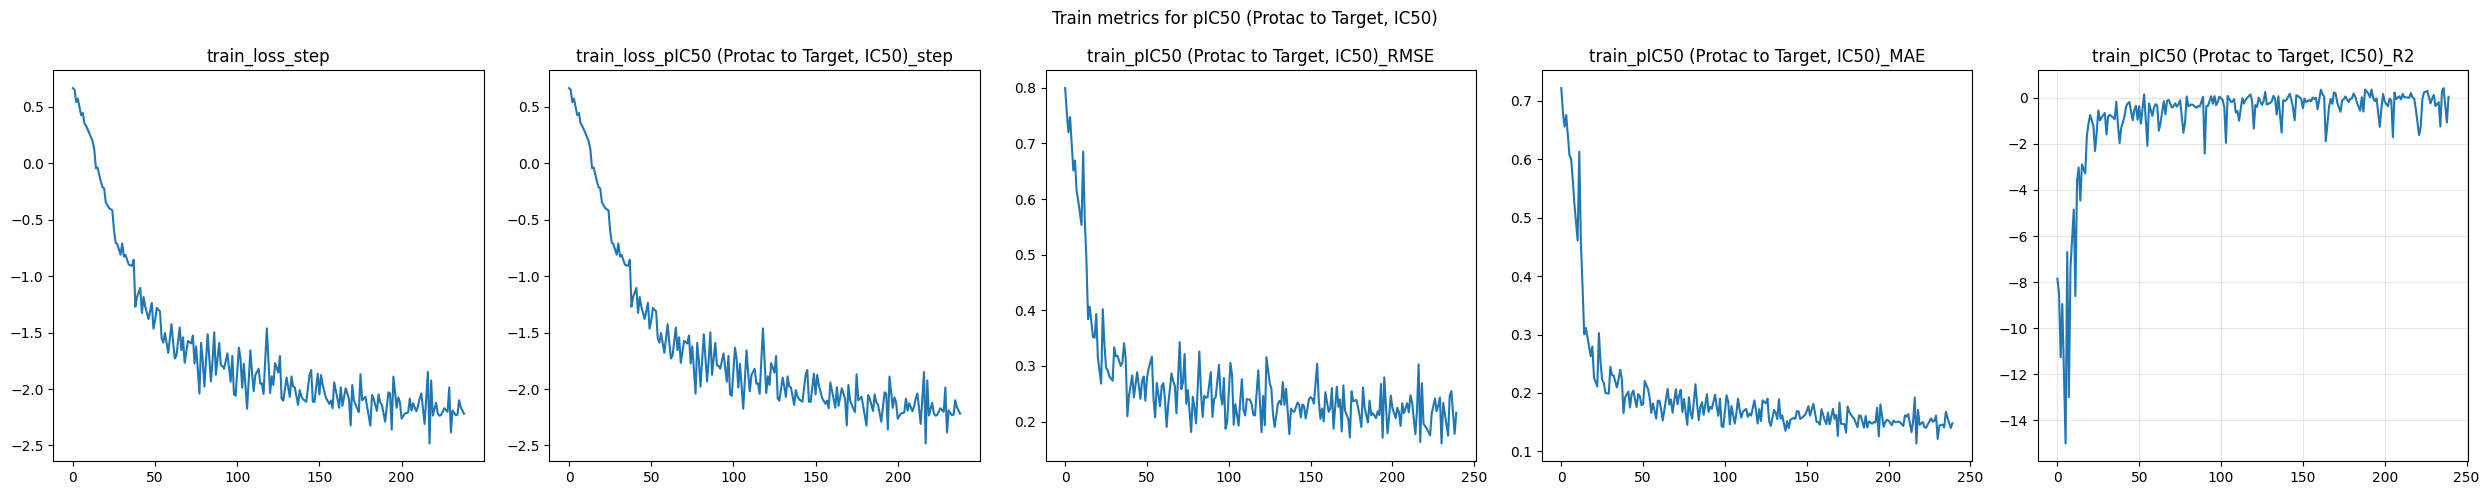

--------------------
Plotting val metrics
--------------------
Label 1: pIC50 (Protac to Target, IC50)


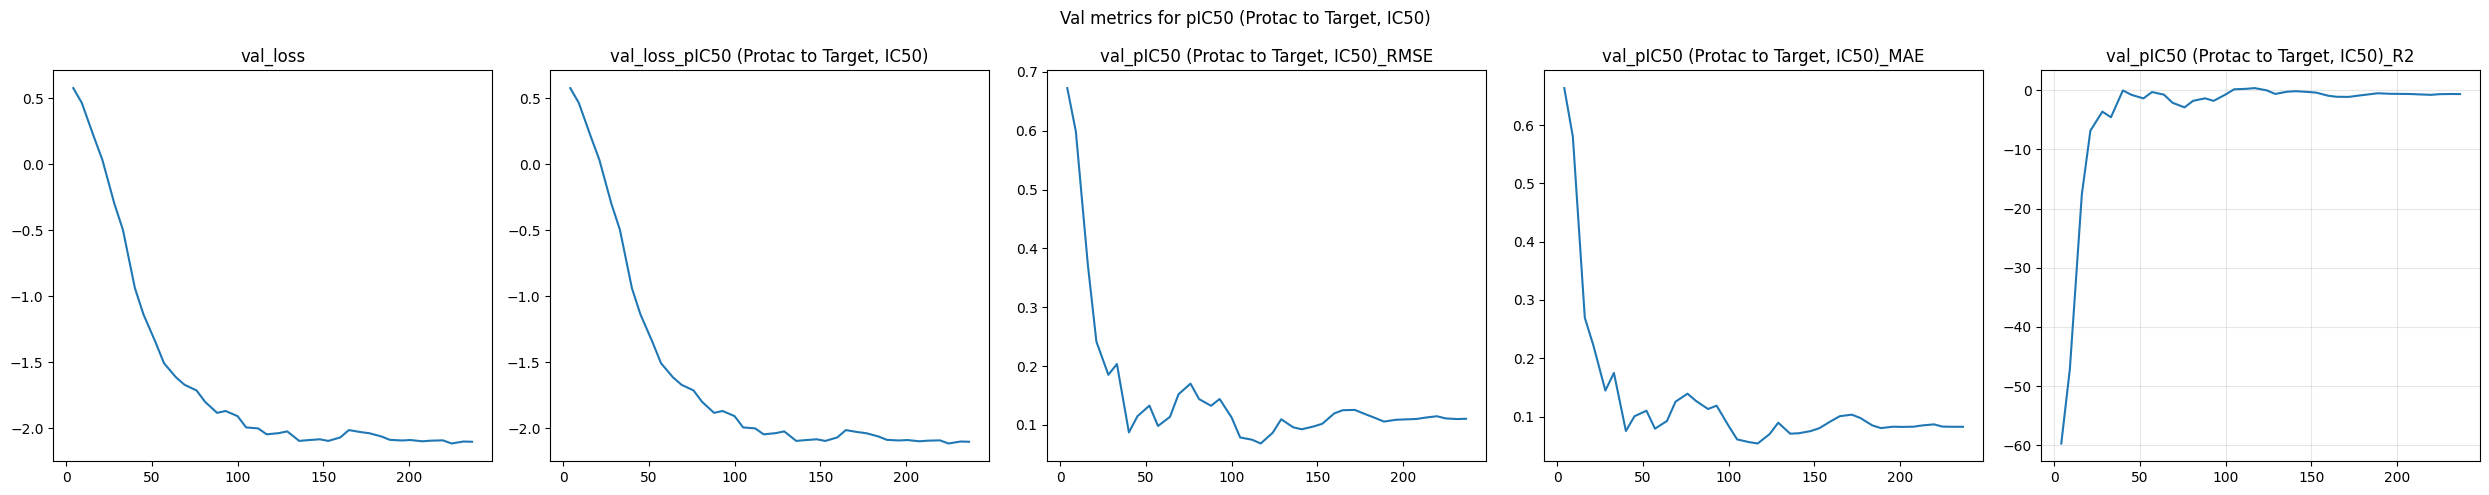

In [1138]:
import os
import matplotlib.pyplot as plt

for stage in ["train", "val"]:
    print("-" * 20)
    print(f"Plotting {stage} metrics")
    print("-" * 20)
    for i, label_name in enumerate(label_weights.keys()):
        print(f"Label {i + 1}: {label_name}")
        metrics_to_plot = [
            f"{stage}_loss" + ("_step" if stage == "train" else ""),
            f"{stage}_loss_{label_name}" + ("_step" if stage == "train" else ""),
            f"{stage}_{label_name}_RMSE",
            f"{stage}_{label_name}_MAE",
            f"{stage}_{label_name}_R2",
        ]
        fig = plot_training_metrics(
            os.path.join(my_temp_dir,"lightning_logs"), metrics_to_plot,
        )
        # Plot fig
        fig.suptitle(f"{stage.title()} metrics for {label_name}")
        plt.grid(axis='both', alpha=0.3)
        plt.tight_layout()
        plt.show()

/Users/ribes/phd/PROTAC-Degradation-Predictor-Multitask/PROTAC-Degradation-Predictor/env-protac-degradation/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=10` in the `DataLoader` to improve performance.
/Users/ribes/phd/PROTAC-Degradation-Predictor-Multitask/PROTAC-Degradation-Predictor/env-protac-degradation/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 131.22it/s]
Predictions shape: torch.Size([128, 1])
Stacked predictions shape: torch.Size([157, 1])
--------------------------------------------------------------------------------
Plotting test predictions for label 1: pIC50 (Protac to Target, IC50)
--------------------------------------------------------------------------------
Number of valid test samples for pIC50 (Protac to Target, IC50): 157
Number of predictions: 157
Number of uncertainties: 157
Number of valid samples after NaN removal: 157
Number of predictions after NaN removal: 157
Number of uncertainties after NaN removal: 157


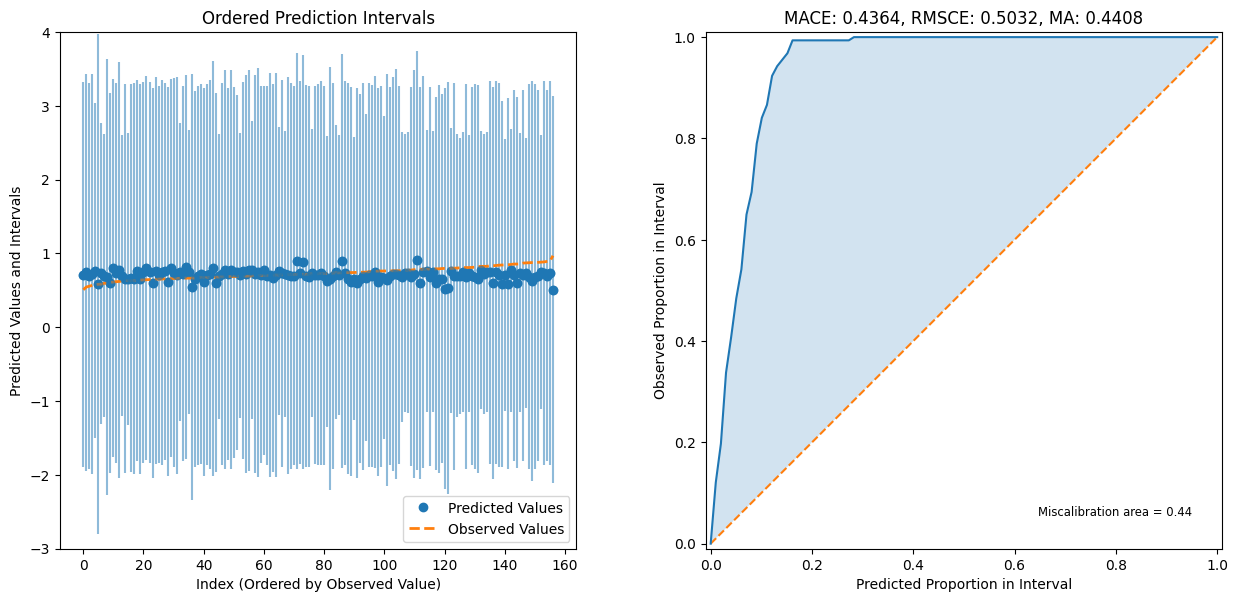

In [1139]:
import uncertainty_toolbox as uct
import numpy as np

def plot_predictions_regression(
        y_pred: np.ndarray,
        pred_std: np.ndarray,
        Y_test: np.ndarray,
        x_test: Optional[np.ndarray] = None,
        skip_xy_plot: bool = True,
) -> plt.Figure:
    """Plot calibration from uq_toolbox.

    Taken from https://github.com/uncertainty-toolbox/uncertainty-toolbox/
    blob/main/examples/viz_readme_figures.py.

    Args:
      y_pred: model mean predictions
      pred_std: predicted standard deviations
      Y_test: test data targets
      x_test: test data inputs
    """
    y_pred = y_pred.squeeze()
    pred_std = pred_std.squeeze()
    Y_test = Y_test.squeeze()
    if x_test is not None:
        x_test = x_test.squeeze()
    # n_subset = min(50, y_pred.shape[0])
    n_subset = y_pred.shape[0]
    mace = uct.mean_absolute_calibration_error(y_pred, pred_std, Y_test)
    ma = uct.miscalibration_area(y_pred, pred_std, Y_test)
    rmsce = uct.root_mean_squared_calibration_error(y_pred, pred_std, Y_test)

    if skip_xy_plot:
        fig, axs = plt.subplots(1, 2, figsize=(15, 8))

        # Make ordered intervals plot
        axs[0] = uct.plot_intervals_ordered(
            y_pred, pred_std, Y_test, n_subset=n_subset, ax=axs[0]
        )

        # Make calibration plot
        axs[1] = uct.plot_calibration(y_pred, pred_std, Y_test, ax=axs[1])

        # Adjust subplots spacing
        fig.subplots_adjust(wspace=0.25)

        axs[1].set_title(f"MACE: {mace:.4f}, RMSCE: {rmsce:.4f}, MA: {ma:.4f}")

        return fig
    else:
        fig, axs = plt.subplots(1, 3)

        # Make xy plot
        axs[0] = uct.plot_xy(y_pred, pred_std, Y_test, x_test, ax=axs[0])

        # Make ordered intervals plot
        axs[1] = uct.plot_intervals_ordered(
            y_pred, pred_std, Y_test, n_subset=n_subset, ax=axs[1]
        )

        # Make calibration plot
        axs[2] = uct.plot_calibration(y_pred, pred_std, Y_test, ax=axs[2])

        # Adjust subplots spacing
        fig.subplots_adjust(wspace=0.25)

        axs[2].set_title(f"MACE: {mace:.4f}, RMSCE: {rmsce:.4f}, MA: {ma:.4f}")

        return fig

preds = trainer.predict(der_model, dataloaders=protac_dm.test_dataloader())
# Stack predictions from all batches
print(f"Predictions shape: {preds[0]['pred'].shape}")  # Should be (batch_size, n_targets)
preds = {k: torch.cat([p[k] for p in preds], dim=0) for k in preds[0].keys()}
print(f"Stacked predictions shape: {preds['pred'].shape}")  # Should be (n_samples, n_targets)

# Assemble the labels from the batches in the test dataloader
labels = {}
for batch in protac_dm.test_dataloader():
    for i, label_name in enumerate(label_weights.keys()):
        if label_name not in labels:
            labels[label_name] = batch[label_name]
        else:
            labels[label_name] = torch.cat((labels[label_name], batch[label_name]), dim=0)

for i, label_name in enumerate(label_weights.keys()):
    print("-" * 80)
    print(f"Plotting test predictions for label {i + 1}: {label_name}")
    print("-" * 80)
    
    # Remove NaN values corresponding to missing labels
    y_test = labels[label_name].cpu().numpy()
    mask = ~np.isnan(y_test)
    y_test = y_test[mask]
    print(f"Number of valid test samples for {label_name}: {len(y_test)}")
    print(f"Number of predictions: {preds[f'pred_{label_name}'].shape[0]}")
    print(f"Number of uncertainties: {preds[f'pred_uct_{label_name}'].shape[0]}")
    print(f"Number of valid samples after NaN removal: {mask.sum()}")
    preds[f"pred_{label_name}"] = preds[f"pred_{label_name}"][mask]
    preds[f"pred_uct_{label_name}"] = preds[f"pred_uct_{label_name}"][mask]
    print(f"Number of predictions after NaN removal: {preds[f'pred_{label_name}'].shape[0]}")
    print(f"Number of uncertainties after NaN removal: {preds[f'pred_uct_{label_name}'].shape[0]}")
    
    fig = plot_predictions_regression(
        y_pred=preds[f"pred_{label_name}"].cpu().numpy(),
        pred_std=preds[f"pred_uct_{label_name}"].cpu().numpy(),
        Y_test=y_test,
        x_test=None,
    )
    plt.show()
    plt.close()

In [1140]:
import pandas as pd

val_metrics = trainer.validate(der_model, dataloaders=protac_dm.val_dataloader(), verbose=0)[0]
test_metrics = trainer.test(der_model, dataloaders=protac_dm.test_dataloader(), verbose=0)[0]

# Make a dataframe to summarize the val and test metrics
print()
summary_data = []
for elem in sorted(list(val_metrics.keys())):
    elem = elem.replace("val_", "").replace("test_", "")
    summary_data.append({
        "metric": elem,
        "val": val_metrics.get(f"val_{elem}"),
        "test": test_metrics.get(f"test_{elem}"),
    })
    
summary_df = pd.DataFrame(summary_data).round(2)
print(summary_df.to_markdown(index=False))

/Users/ribes/phd/PROTAC-Degradation-Predictor-Multitask/PROTAC-Degradation-Predictor/env-protac-degradation/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=10` in the `DataLoader` to improve performance.


Validation DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 143.08it/s]

/Users/ribes/phd/PROTAC-Degradation-Predictor-Multitask/PROTAC-Degradation-Predictor/env-protac-degradation/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=10` in the `DataLoader` to improve performance.



Testing DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 69.51it/s] 

| metric                                       |   val |   test |
|:---------------------------------------------|------:|-------:|
| loss                                         | -2.1  |  -2.15 |
| loss_pIC50 (Protac to Target, IC50)          | -2.1  |  -2.15 |
| pIC50 (Protac to Target, IC50)_MAE           |  0.08 |   0.09 |
| pIC50 (Protac to Target, IC50)_R2            | -0.69 |  -0.94 |
| pIC50 (Protac to Target, IC50)_RMSE          |  0.11 |   0.12 |
| valid_samples_pIC50 (Protac to Target, IC50) | 86    | 109.71 |



```
| metric                                          |   val |   test |
|:------------------------------------------------|------:|-------:|
| Dmax (%) (DC50/Dmax)_MAE                        |  0.16 |   0.14 |
| Dmax (%) (DC50/Dmax)_R2                         |  0.69 |   0.76 |
| Dmax (%) (DC50/Dmax)_RMSE                       |  0.22 |   0.19 |
| loss                                            |  0.78 |   0.21 |
| loss_Dmax (%) (DC50/Dmax)                       | -2.24 |  -2.49 |
| loss_pDC50 (DC50/Dmax)                          |  1.51 |   0.77 |
| loss_pIC50 (Cellular activities, IC50)          |  0.51 |   0.39 |
| loss_pIC50 (Protac to Target, IC50)             |  3.48 |   1.74 |
| pDC50 (DC50/Dmax)_MAE                           |  0.98 |   0.76 |
| pDC50 (DC50/Dmax)_R2                            |  0.2  |   0.27 |
| pDC50 (DC50/Dmax)_RMSE                          |  2.03 |   1.33 |
| pIC50 (Cellular activities, IC50)_MAE           |  0.61 |   0.56 |
| pIC50 (Cellular activities, IC50)_R2            |  0.65 |   0.75 |
| pIC50 (Cellular activities, IC50)_RMSE          |  0.85 |   0.75 |
| pIC50 (Protac to Target, IC50)_MAE              |  0.98 |   1.07 |
| pIC50 (Protac to Target, IC50)_R2               |  0.15 |   0.07 |
| pIC50 (Protac to Target, IC50)_RMSE             |  2.06 |   2.43 |
| valid_samples_Dmax (%) (DC50/Dmax)              | 26.12 |  29.62 |
| valid_samples_pDC50 (DC50/Dmax)                 | 40.61 |  38.62 |
| valid_samples_pIC50 (Cellular activities, IC50) | 66.22 |  67.86 |
| valid_samples_pIC50 (Protac to Target, IC50)    | 27.84 |  26.38 |

Feature dimensions: {'mol': 768, 'poi': 320, 'e3': 320, 'cell': 768}
Label weights:
  Dmax (%) (DC50/Dmax): 0.2371
  pDC50 (DC50/Dmax): 0.3178
  pIC50 (Cellular activities, IC50): 0.5481
  pIC50 (Protac to Target, IC50): 0.2330
DERModel(
  (model): RegressionModel(
    (backbone): Backbone(
      (input_proj): ModuleDict(
        (mol): InputProjector(
          (linear): Linear(in_features=768, out_features=256, bias=True)
          (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        )
        (poi): InputProjector(
          (linear): Linear(in_features=320, out_features=256, bias=True)
          (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        )
        (e3): InputProjector(
          (linear): Linear(in_features=320, out_features=256, bias=True)
          (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        )
        (cell): InputProjector(
          (linear): Linear(in_features=768, out_features=256, bias=True)
          (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        )
      )
      (trunk): Sequential(
        (0): GPTStyleFeedForward(
          (ln): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (fc1): Linear(in_features=256, out_features=256, bias=False)
          (fc2): Linear(in_features=256, out_features=256, bias=False)
          (dropout): Dropout(p=0.3, inplace=False)
        )
      )
    )
    (lin_head): Linear(in_features=256, out_features=16, bias=False)
    (der_layer): DERLayer()
  )
  (loss_functions): ModuleDict(
    (Dmax (%) (DC50/Dmax)): DERLoss()
    (pDC50 (DC50/Dmax)): DERLoss()
    (pIC50 (Cellular activities, IC50)): DERLoss()
    (pIC50 (Protac to Target, IC50)): DERLoss()
  )
  (metrics): ModuleDict(
    (train_Dmax (%) (DC50/Dmax)): MetricCollection(
      (MAE): MeanAbsoluteError()
      (R2): R2Score()
      (RMSE): MeanSquaredError(),
      prefix=train_Dmax (%) (DC50/Dmax)_
    )
    (val_Dmax (%) (DC50/Dmax)): MetricCollection(
      (MAE): MeanAbsoluteError()
      (R2): R2Score()
      (RMSE): MeanSquaredError(),
      prefix=val_Dmax (%) (DC50/Dmax)_
    )
    (test_Dmax (%) (DC50/Dmax)): MetricCollection(
      (MAE): MeanAbsoluteError()
      (R2): R2Score()
      (RMSE): MeanSquaredError(),
      prefix=test_Dmax (%) (DC50/Dmax)_
    )
    (train_pDC50 (DC50/Dmax)): MetricCollection(
      (MAE): MeanAbsoluteError()
      (R2): R2Score()
      (RMSE): MeanSquaredError(),
      prefix=train_pDC50 (DC50/Dmax)_
    )
    (val_pDC50 (DC50/Dmax)): MetricCollection(
      (MAE): MeanAbsoluteError()
      (R2): R2Score()
      (RMSE): MeanSquaredError(),
      prefix=val_pDC50 (DC50/Dmax)_
    )
    (test_pDC50 (DC50/Dmax)): MetricCollection(
      (MAE): MeanAbsoluteError()
      (R2): R2Score()
      (RMSE): MeanSquaredError(),
      prefix=test_pDC50 (DC50/Dmax)_
    )
    (train_pIC50 (Cellular activities, IC50)): MetricCollection(
      (MAE): MeanAbsoluteError()
      (R2): R2Score()
      (RMSE): MeanSquaredError(),
      prefix=train_pIC50 (Cellular activities, IC50)_
    )
    (val_pIC50 (Cellular activities, IC50)): MetricCollection(
      (MAE): MeanAbsoluteError()
      (R2): R2Score()
      (RMSE): MeanSquaredError(),
      prefix=val_pIC50 (Cellular activities, IC50)_
    )
    (test_pIC50 (Cellular activities, IC50)): MetricCollection(
      (MAE): MeanAbsoluteError()
      (R2): R2Score()
      (RMSE): MeanSquaredError(),
      prefix=test_pIC50 (Cellular activities, IC50)_
    )
    (train_pIC50 (Protac to Target, IC50)): MetricCollection(
      (MAE): MeanAbsoluteError()
      (R2): R2Score()
      (RMSE): MeanSquaredError(),
      prefix=train_pIC50 (Protac to Target, IC50)_
    )
    (val_pIC50 (Protac to Target, IC50)): MetricCollection(
      (MAE): MeanAbsoluteError()
      (R2): R2Score()
      (RMSE): MeanSquaredError(),
      prefix=val_pIC50 (Protac to Target, IC50)_
    )
    (test_pIC50 (Protac to Target, IC50)): MetricCollection(
      (MAE): MeanAbsoluteError()
      (R2): R2Score()
      (RMSE): MeanSquaredError(),
      prefix=test_pIC50 (Protac to Target, IC50)_
    )
  )
)
```

```python
trunk_size = 1
trunk_type = "gpt"  # "gpt" or "mlp"
hidden_dim = 256
dropout = 0.3
input_norm = "layer" # "layer" or "batch" or None
trunk_norm = "layer" # "layer" or "batch" or None
learning_rate = 1e-3
warmup_ratio = 0.10
feature_dims = datasets["train"].shapes()

print("Feature dimensions:", feature_dims)

# Define custom weights for each label loss term
# The weights can be based on the number of non-missing samples for each label
num_train_data = len(datasets["train"])

label_arrays = {
    "Dmax (%) (DC50/Dmax)": np.array(dataset["train"].data["Dmax (%) (DC50/Dmax)"]),
    "pDC50 (DC50/Dmax)": np.array(dataset["train"].data["pDC50 (DC50/Dmax)"]),
    "pIC50 (Cellular activities, IC50)": np.array(dataset["train"].data["pIC50 (Cellular activities, IC50)"]),
    "pIC50 (Protac to Target, IC50)": np.array(dataset["train"].data["pIC50 (Protac to Target, IC50)"]),
}

label_weights = {
    "Dmax (%) (DC50/Dmax)": 1 - np.isnan(label_arrays["Dmax (%) (DC50/Dmax)"]).sum() / num_train_data,
    "pDC50 (DC50/Dmax)": 1 - np.isnan(label_arrays["pDC50 (DC50/Dmax)"]).sum() / num_train_data,
    "pIC50 (Cellular activities, IC50)": 1 - np.isnan(label_arrays["pIC50 (Cellular activities, IC50)"]).sum() / num_train_data,
    "pIC50 (Protac to Target, IC50)": 1 - np.isnan(label_arrays["pIC50 (Protac to Target, IC50)"]).sum() / num_train_data,
}

print("Label weights:")
for label, weight in label_weights.items():
    print(f"  {label}: {weight:.4f}")

# Define different DER loss coefficients (regularization) for each label
der_loss_coeffs = {
    "Dmax (%) (DC50/Dmax)": 0.2,
    "pDC50 (DC50/Dmax)": 0.2,
    "pIC50 (Cellular activities, IC50)": 0.2,
    "pIC50 (Protac to Target, IC50)": 0.2,
}
```

## Extract Embeddings

In [ ]:
protac_dm = PROTACDataModule(
    datasets_dict=datasets,
    batch_size=16,
    num_workers=0,
    pin_memory=True,
)

protac_dm.setup()
batch = next(iter(protac_dm.train_dataloader()))
extracted_embeddings = der_model.extract_embeddings(batch)
print("Extracted embeddings shape:", extracted_embeddings.shape, extracted_embeddings.mean())  # Should be (batch_size, hidden_dim)

---

## Legacy Code

In [ ]:
from sklearn.datasets import make_regression
import numpy as np


n_samples = 2000
feature_dims = [256, 64, 64, 128]
n_targets = 3
random_state = 42
label_noise = 0.1

rng = np.random.default_rng(random_state)

# Generate features with different dimensions
features = [make_regression(n_samples=n_samples, n_features=dim, noise=0.1)[0] for dim in feature_dims]

# Concatenate all features horizontally
X = np.hstack(features)

# Generate real-valued labels
y = rng.normal(loc=0, scale=1, size=(n_samples, n_targets))
y += rng.uniform(-label_noise, label_noise, size=(n_samples, n_targets))

# Skew the labels to be non-negative
min_label = np.min(y)
if min_label < 0:
    y -= min_label + rng.uniform(0.1, 0.5)  # Shift to ensure non-negativity

# Zero-inflate one of the labels randomly
if n_targets > 0:
    zero_inflate_idx = rng.integers(0, n_targets)
    # Set a fraction of the label to zero
    zero_fraction = rng.uniform(0.10, 0.15)  # 5% to 10% zero
    num_zeros = int(n_samples * zero_fraction)
    zero_indices = rng.choice(n_samples, size=num_zeros, replace=False)
    y[zero_indices, zero_inflate_idx] = 0.0  # Set to zero
    
    # scale them between 0 and 1
    y[:, zero_inflate_idx] = (y[:, zero_inflate_idx] - np.min(y[:, zero_inflate_idx])) / (np.max(y[:, zero_inflate_idx]) - np.min(y[:, zero_inflate_idx]))

# Print the shapes of the generated data
print(f'Features shape: {X.shape}')
print(f'Targets shape: {y.shape}')

In [ ]:
# Plot the label distributions in the same plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for j in range(n_targets):
    y_val = y[:, j]
    plt.subplot(1, n_targets, j + 1)
    plt.hist(y_val, bins=30, alpha=0.7, label=f'Label {j + 1}', color=f'C{j}')
    plt.title(f"Distribution of label {j + 1}")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import torch
from torch.utils.data import Dataset

class ToyRegressionDataset(Dataset):
    """
    PyTorch Dataset for the toy regression data.

    Args:
        X (np.ndarray): Feature matrix of shape (n_samples, n_features).
        y (np.ndarray): Target matrix of shape (n_samples, n_targets).
        feature_dims (dict): Dictionary mapping feature names to their dimensions.
    """
    def __init__(self, X, y, feature_dims, label_names=None):
        self.X = X
        self.y = y
        self.n_targets = y.shape[1] if y.ndim > 1 else 1
        self.feature_dims = feature_dims
        assert self.X.shape[1] == sum(feature_dims.values()), f"Feature dimensions do not match: {self.X.shape[1]} != {sum(feature_dims.values())}"
        self.label_names = label_names if label_names is not None else [f'label_{i}' for i in range(self.n_targets)]

        # Store feature names and their start/end indices
        self.feature_slices = {}
        start = 0
        for k, dim in self.feature_dims.items():
            end = start + dim
            self.feature_slices[k] = (start, end)
            start = end

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        item = {}
        for k, (start, end) in self.feature_slices.items():
            item[k] = self.X[idx, start:end]
        # Add labels for each target
        for j, label_name in enumerate(self.label_names):
            item[label_name] = self.y[idx, j] if self.n_targets > 1 else self.y[idx]
        # Add a dimension 1 in front of the concatenated labels
        item["labels"] = np.expand_dims(self.y[idx], axis=0) if self.n_targets > 1 else np.array([self.y[idx]])
        return item

feature_dims = {
    'feature_0': 256,
    'feature_1': 64,
    'feature_2': 64,
    'feature_3': 128,
}
toy_dataset = ToyRegressionDataset(X, y, feature_dims)
for k, v in toy_dataset[0].items():
    print(f"{k}: {v.shape} - {v.dtype}")
print()

from torch.utils.data import DataLoader
toy_dataloader = DataLoader(toy_dataset, batch_size=32, shuffle=True)
for batch in toy_dataloader:
    for k, v in batch.items():
        print(f"{k}: {v.shape} - {v.dtype}")
    break

In [ ]:
import pytorch_lightning as pl
from torch.utils.data import DataLoader, Subset

class ToyRegressionDataModule(pl.LightningDataModule):
    def __init__(
        self,
        n_samples=2000,
        feature_dims={'feature_0': 256, 'feature_1': 64, 'feature_2': 64, 'feature_3': 128},
        label_names=None,
        n_targets=3,
        label_noise=0.1,
        random_state=42,
        batch_size=64,
        num_workers=0,
    ):
        super().__init__()
        self.n_samples = n_samples
        self.feature_dims = feature_dims
        self.n_targets = n_targets
        self.label_noise = label_noise
        self.random_state = random_state
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.label_names = label_names if label_names is not None else [f'label_{i}' for i in range(n_targets)]
        if self.n_targets > 0:
            self.zero_inflate_idx = rng.integers(0, self.n_targets)
            self.zero_inflated_label = self.label_names[zero_inflate_idx]

    def prepare_data(self):
        pass

    def setup(self, stage=None):
        rng = np.random.default_rng(self.random_state)
        # Use feature_dims dict to generate features
        features = [make_regression(n_samples=self.n_samples, n_features=dim, noise=0.1)[0] 
                    for dim in self.feature_dims.values()]
        X = np.hstack(features)
        y = rng.normal(loc=0, scale=1, size=(self.n_samples, self.n_targets))
        y += rng.uniform(-self.label_noise, self.label_noise, size=(self.n_samples, self.n_targets))
        min_label = np.min(y)
        if min_label < 0:
            y -= min_label + rng.uniform(0.1, 0.5)
        if self.n_targets > 0:
            zero_inflate_idx = self.zero_inflate_idx
            zero_fraction = rng.uniform(0.10, 0.15)
            num_zeros = int(self.n_samples * zero_fraction)
            zero_indices = rng.choice(self.n_samples, size=num_zeros, replace=False)
            y[zero_indices, zero_inflate_idx] = 0.0
            y[:, zero_inflate_idx] = (y[:, zero_inflate_idx] - np.min(y[:, zero_inflate_idx])) / (np.max(y[:, zero_inflate_idx]) - np.min(y[:, zero_inflate_idx]))

        # Randomly set 15% of the labels to NaN
        nan_fraction = 0.15
        num_nans = int(self.n_samples * nan_fraction)
        nan_indices = rng.choice(self.n_samples, size=num_nans, replace=False)
        y[nan_indices, rng.integers(0, self.n_targets, size=num_nans)] = np.nan

        # Convert X and y to numpy arrays
        X = np.array(X, dtype=np.float32)
        y = np.array(y, dtype=np.float32)

        # Split indices
        indices = np.arange(self.n_samples)
        rng.shuffle(indices)
        train_end = int(0.7 * self.n_samples)
        val_end = int(0.9 * self.n_samples)
        self.train_indices = indices[:train_end]
        self.val_indices = indices[train_end:val_end]
        self.test_indices = indices[val_end:]
    
        # Create the datasets
        self.train_dataset = ToyRegressionDataset(
            X[self.train_indices],
            y[self.train_indices],
            self.feature_dims,
            self.label_names,
        )
        self.val_dataset = ToyRegressionDataset(
            X[self.val_indices],
            y[self.val_indices],
            self.feature_dims,
            self.label_names,
        )
        self.test_dataset = ToyRegressionDataset(
            X[self.test_indices],
            y[self.test_indices],
            self.feature_dims,
            self.label_names,
        )

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
        )


n_samples = 2000
feature_dims = {
    'feature_0': 256,
    'feature_1': 64,
    'feature_2': 64,
    'feature_3': 128,
}
n_targets = 3
label_noise = 0.1
random_state = 42

dm = ToyRegressionDataModule(
    n_samples=n_samples,
    feature_dims=feature_dims,
    n_targets=n_targets,
    label_noise=label_noise,
    random_state=random_state,
    batch_size=64,
    num_workers=0,
)

# Get a batch from the train dataloader
dm.setup()
train_loader = dm.test_dataloader()
for batch in train_loader:
    for k, v in batch.items():
        print(f"{k}: {v.shape} - {v.dtype}")
    print()
    # break

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Optional

class GPTStyleFeedForward(nn.Module):
    """
    Pre-LN feed-forward block used in decoder-only Transformers (Radford et al., 2018/GPT family).

    Structure (for input X ∈ R^{BxTxd_model}):
        Y = X + Dropout( W2 * φ( W1 * LN(X) ) )
    where φ is GELU, and W1,W2 are linear (affine) maps with optional bias.

    Parameters
    ----------
    d_model : int
        Hidden size of the model.
    d_ff : Optional[int]
        Inner width of the MLP. Defaults to 4 * d_model if None.
    dropout : float
        Dropout probability applied after the second linear.
    bias : bool
        Whether to use bias terms in the two linear layers. In GPT-style models this is True. 
        (See HF GPT-2 `Conv1D` layers, which include `bias`.) 
    eps : float
        Epsilon for LayerNorm stability.

    Notes
    -----
    * This follows the *pre-norm* residual layout used in GPT-1/2: LayerNorm → MLP → residual add.
    * Activation is GELU, as in GPT-2.
    * Expected input shape is (batch, seq, d_model); the module is position-wise.
    """
    def __init__(
        self,
        d_model: int,
        d_ff: Optional[int] = None,
        dropout: float = 0.0,
        bias: bool = True,
        eps: float = 1e-5,
    ) -> None:
        super().__init__()
        inner = 4 * d_model if d_ff is None else d_ff

        # Pre-norm
        self.ln = nn.LayerNorm(d_model, eps=eps)

        # Two affine projections (bias enabled by default, matching GPT practice)
        self.fc1 = nn.Linear(d_model, inner, bias=bias)
        self.fc2 = nn.Linear(inner, d_model, bias=bias)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass.

        Args
        ----
        x : Tensor of shape (B, T, d_model)

        Returns
        -------
        Tensor of shape (B, T, d_model)
        """
        # Pre-norm residual block
        h = self.ln(x)
        h = F.gelu(self.fc1(h))       # position-wise nonlinearity
        h = self.fc2(h)
        h = self.dropout(h)
        return x + h                   # residual add

class InputScaler(nn.Module):
    """
    Input scaling layer that applies a linear transformation to the input features.

    Parameters
    ----------
    in_features : int
        Number of input features.
    out_features : int
        Number of output features.
    bias : bool, optional
        Whether to include a bias term in the linear transformation. Default is True.
    norm : bool, optional
        Whether to apply Layer Normalization before the linear transformation. Default is False.
    """
    def __init__(
            self,
            in_features: int,
            out_features: int,
            bias: bool = True,
            norm: bool = False,
    ):
        super().__init__()
        self.norm = None
        if norm:
            self.norm = nn.LayerNorm(in_features)
        self.linear = nn.Linear(in_features, out_features, bias=bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.norm is not None:
            x = self.norm(x)
        x = self.linear(x)
        # Divide by the square root of the output dimension to maintain variance
        # This is a common practice in Transformer models to stabilize training
        return F.softmax(x / (self.linear.out_features ** 0.5), dim=-1)

In [ ]:
from lightning_uq_box.viz_utils import (
    plot_calibration_uq_toolbox,
    plot_predictions_regression,
    plot_toy_regression_data,
    plot_training_metrics,
)
from lightning_uq_box.uq_methods.loss_functions import DERLoss
from lightning_uq_box.uq_methods.deep_evidential_regression import DERLayer

In [ ]:
pl.seed_everything(42)

In [ ]:
from typing import List, Dict
from torch import nn
import torch

class Backbone(nn.Module):
    """
    Backbone network for feature embedding and trunk processing.
    """
    def __init__(
            self,
            feature_dims: Dict[str, int],
            hidden_dim: int = 128,
            trunk_size: int = 1,
            dropout: float = 0.1,
            norm: bool = False,
    ):
        super().__init__()
        self.input_embedding = nn.ModuleDict({
            k: InputScaler(d, hidden_dim, norm=norm) for k, d in feature_dims.items()
        })
        self.trunk = nn.Sequential(
            *[GPTStyleFeedForward(hidden_dim, hidden_dim, dropout) for _ in range(trunk_size)]
        )

    def forward(self, batch: Dict[str, torch.Tensor]) -> torch.Tensor:
        embedded_features = [self.input_embedding[k](batch[k]) for k in self.input_embedding.keys()]
        x = torch.stack(embedded_features, dim=-1)  # (batch_size, hidden_dim, n_features)
        x = x.sum(dim=-1)  # (batch_size, hidden_dim)
        x = self.trunk(x)
        return x

class RegressionModel(nn.Module):
    """
    Regression model with backbone, linear head, and DER layer.
    """
    def __init__(
            self,
            feature_dims: Dict[str, int],
            n_targets: int = 1,
            trunk_size: int = 1,
            hidden_dim: int = 128,
            dropout: float = 0.1,
            norm: bool = False,
    ):
        super().__init__()
        self.backbone = Backbone(
            feature_dims=feature_dims,
            hidden_dim=hidden_dim,
            trunk_size=trunk_size,
            dropout=dropout,
            norm=norm,
        )
        self.lin_head = nn.Linear(hidden_dim, 4 * n_targets, bias=False)
        self.der_layer = DERLayer()

    def forward(self, batch: Dict[str, torch.Tensor], return_embeddings: bool = False) -> torch.Tensor:
        embedding = self.backbone(batch)
        x = self.lin_head(embedding)
        x = x.view(x.size(0), 4, -1)
        x = self.der_layer(x)
        if return_embeddings:
            return x, embedding
        return x

# Example usage
feature_dims = {
    'feature_0': 256,
    'feature_1': 64,
    'feature_2': 64,
    'feature_3': 128,
}
model = RegressionModel(
    feature_dims=feature_dims,
    n_targets=3,
    trunk_size=2,
    hidden_dim=128,
    dropout=0.1
)
# Print the model architecture
print(model)
# Example input batch
batch = {
    'feature_0': torch.randn(8, 256),
    'feature_1': torch.randn(8, 64),
    'feature_2': torch.randn(8, 64),
    'feature_3': torch.randn(8, 128),
}
# Forward pass
output = model(batch)
print("Output shape:", output.shape)  # Should be (8, 4, 3) for 8 samples, 4 outputs per target label
# Output shape: (8, 4, 3)

# Run it through a DER layer
print("DER output shape:", output.shape)  # Should be (8, 4, 3) for 8 samples, 4 outputs per target label
# Output shape: (8, 4, 3)

# Test with the DERLoss
der_loss = DERLoss(coeff=0.2)
loss = der_loss(output, torch.randn(8, 1, 3))
print("Loss:", loss.item())  # Should print a scalar loss value

In [ ]:
import tempfile

my_temp_dir = tempfile.mkdtemp()

In [ ]:
from lightning.pytorch.loggers import CSVLogger
from lightning_uq_box.uq_methods.utils import default_regression_metrics

class DERModel(pl.LightningModule):

    def __init__(
            self,
            label_names: List[str] = None,
            label_weights: Dict[str, float] = None,
            der_loss_coeffs: Dict[str, float] = None,
            default_der_loss_coeff: float = 0.01,
            learning_rate: float = 1e-3,
            **model_kwargs: Dict[str, int],
    ):
        super().__init__()
        self.save_hyperparameters()

        self.learning_rate = learning_rate
        self.model = RegressionModel(**model_kwargs)

        self.label_names = label_names if label_names is not None else [f"label_{i}" for i in range(model_kwargs.get("n_targets", 1))]

        # Create explicit mapping from label names to output indices
        self.label_to_idx = {name: i for i, name in enumerate(self.label_names)}

        # Set up label weights - default to equal weights if not provided
        if label_weights is None:
            self.label_weights = {name: 1.0 for name in self.label_names}
        else:
            # Ensure all labels have weights, default missing ones to 1.0
            self.label_weights = {name: label_weights.get(name, 1.0) for name in self.label_names}
        
        # Normalize weights so they sum to the number of labels (maintains scale)
        total_weight = sum(self.label_weights.values())
        if total_weight > 0:
            self.label_weights = {name: weight * len(self.label_names) / total_weight 
                                 for name, weight in self.label_weights.items()}

        # Create individual DER loss functions for each label
        self.loss_functions = nn.ModuleDict()
        for label_name in self.label_names:
            coeff = der_loss_coeffs.get(label_name, default_der_loss_coeff) if der_loss_coeffs else default_der_loss_coeff
            self.loss_functions[label_name] = DERLoss(coeff)

        # Add metrics for logging
        self.metrics = {}
        for label in self.label_names:
            for stage in ["train", "val", "test"]:
                metric_id = f"{stage}_{label}"
                self.metrics[metric_id] = default_regression_metrics(f"{metric_id}_")
        # NOTE: Metrics are nn.Module, so they must be registered accordingly
        self.metrics = nn.ModuleDict(self.metrics)

    def forward(self, batch: Dict[str, torch.Tensor]) -> torch.Tensor:
        return self.model(batch)

    def _prepare_labels_tensor(self, batch: Dict[str, torch.Tensor]) -> torch.Tensor:
        """
        Prepare labels tensor in the correct order for the loss function.
        
        Args:
            batch: Input batch containing labels
            
        Returns:
            torch.Tensor of shape (batch_size, 1, n_targets)
        """
        # Use self.label_to_idx to ensure correct ordering
        labels_list = [batch[label] for label in self.label_names]
        labels = torch.stack(labels_list, dim=-1)  # Shape: (batch_size, n_targets)
        return labels.unsqueeze(1)  # Shape: (batch_size, 1, n_targets)

    def _filter_nan_samples(self, preds: torch.Tensor, targets: torch.Tensor) -> tuple:
        """
        Filter out samples where targets contain NaN values.
        
        Args:
            preds: Predictions tensor
            targets: Target tensor
            
        Returns:
            Tuple of (filtered_preds, filtered_targets)
        """
        valid_mask = ~torch.isnan(targets)
        if valid_mask.sum() == 0:
            # If all samples are NaN, return empty tensors
            return preds[:0], targets[:0]
        
        return preds[valid_mask], targets[valid_mask]

    def _compute_weighted_loss(self, outputs: torch.Tensor, labels: torch.Tensor) -> tuple:
        """
        Compute weighted loss for each label and return the weighted average.
        
        Args:
            outputs: Model outputs of shape (batch_size, 4, n_targets)
            labels: Ground truth labels of shape (batch_size, 1, n_targets)
            
        Returns:
            Tuple of (weighted_loss, per_label_losses, valid_samples_per_label)
        """
        per_label_losses = []
        valid_samples_per_label = {}
        
        for label_name in self.label_names:
            idx = self.label_to_idx[label_name]
            
            # Extract outputs and labels for this specific label
            label_outputs = outputs[:, :, idx:idx+1]  # Shape: (batch_size, 4, 1)
            label_targets = labels[:, :, idx:idx+1]   # Shape: (batch_size, 1, 1)
            
            # Flatten for NaN filtering
            label_targets_flat = label_targets.squeeze(-1).squeeze(-1)  # Shape: (batch_size,)
            
            # Filter out NaN samples
            valid_mask = ~torch.isnan(label_targets_flat)
            n_valid = valid_mask.sum().item()
            valid_samples_per_label[label_name] = n_valid
            
            if n_valid == 0:
                # If all samples are NaN for this label, set loss to 0
                label_loss = torch.tensor(0.0, device=outputs.device, requires_grad=True)
                self.log(f"nan_warning_{label_name}", 1.0, on_step=False, on_epoch=True)
            else:
                # Filter valid samples
                valid_label_outputs = label_outputs[valid_mask]  # Shape: (n_valid, 4, 1)
                valid_label_targets = label_targets[valid_mask]  # Shape: (n_valid, 1, 1)
                
                # Compute loss for this label using its specific loss function
                label_loss = self.loss_functions[label_name](valid_label_outputs, valid_label_targets)
            
            per_label_losses.append(label_loss)
        
        # Stack losses and apply weights
        per_label_losses = torch.stack(per_label_losses)  # Shape: (n_targets,)
        
        # Apply weights - only to labels that have valid samples
        weighted_losses = []
        total_weight = 0.0
        
        for i, label_name in enumerate(self.label_names):
            if valid_samples_per_label[label_name] > 0:
                weight = self.label_weights[label_name]
                weighted_losses.append(per_label_losses[i] * weight)
                total_weight += weight
        
        if len(weighted_losses) == 0:
            # All labels have NaN - return zero loss
            weighted_loss = torch.tensor(0.0, device=outputs.device, requires_grad=True)
        else:
            # Compute weighted average
            weighted_loss = torch.stack(weighted_losses).sum() / max(total_weight, 1e-8)
        
        return weighted_loss, per_label_losses, valid_samples_per_label

    def _process_batch(self, batch: Dict[str, torch.Tensor], stage: str):
        """
        Helper method to process a batch for training, validation, or testing.
        Reduces code duplication and ensures consistent logic.
        """
        outputs = self(batch)
        labels = self._prepare_labels_tensor(batch)
        
        # Compute weighted loss and per-label losses
        loss, per_label_losses, valid_samples_count = self._compute_weighted_loss(outputs, labels)
        
        # Log overall loss
        self.log(f"{stage}_loss", loss, on_step=(stage=="train"), on_epoch=True, prog_bar=True)
        
        # Log per-label losses and valid sample counts
        for i, label_name in enumerate(self.label_names):
            self.log(f"{stage}_loss_{label_name}", per_label_losses[i], 
                    on_step=(stage=="train"), on_epoch=True, prog_bar=False)
            self.log(f"{stage}_valid_samples_{label_name}", valid_samples_count[label_name], 
                    on_step=False, on_epoch=True, prog_bar=False)

        # Update metrics for each label using explicit mapping (with NaN filtering)
        for label_name, output_idx in self.label_to_idx.items():
            preds = outputs[:, 0, output_idx]  # Get predictions for this label
            target = batch[label_name]  # Get target for this label
            
            # Filter out NaN values for metrics computation
            filtered_preds, filtered_target = self._filter_nan_samples(preds, target)
            
            if len(filtered_target) > 0:  # Only compute metrics if we have valid samples
                metrics_key = f"{stage}_{label_name}"
                if stage == "train":
                    # For training, compute and log metrics immediately
                    scores = self.metrics[metrics_key](filtered_preds, filtered_target)
                    self.log_dict(scores)
                else:
                    # For validation/test, just update metrics
                    self.metrics[metrics_key].update(filtered_preds, filtered_target)
        
        return loss

    def training_step(self, batch: Dict[str, torch.Tensor], batch_idx: int) -> torch.Tensor:
        return self._process_batch(batch, "train")

    def validation_step(self, batch: Dict[str, torch.Tensor], batch_idx: int) -> torch.Tensor:
        return self._process_batch(batch, "val")

    def on_validation_epoch_end(self):
        for label_name in self.label_names:
            metrics_key = f"val_{label_name}"
            metrics = self.metrics[metrics_key].compute()
            self.log_dict(metrics)
            self.metrics[metrics_key].reset()

    def test_step(self, batch: Dict[str, torch.Tensor], batch_idx: int) -> torch.Tensor:
        return self._process_batch(batch, "test")

    def on_test_epoch_end(self):
        for label_name in self.label_names:
            metrics_key = f"test_{label_name}"
            metrics = self.metrics[metrics_key].compute()
            self.log_dict(metrics)
            self.metrics[metrics_key].reset()

    def predict_step(
        self, X: torch.Tensor, batch_idx: int = 0, dataloader_idx: int = 0
    ) -> Dict[str, torch.Tensor]:
        """Prediction Step Deep Evidential Regression.

        Args:
            X: prediction batch of shape [batch_size x input_dims]
            batch_idx: the index of this batch
            dataloader_idx: the index of the dataloader

        Returns:
            dictionary with predictions and uncertainty measures
        """
        with torch.no_grad():
            pred = self.forward(X)  # [batch_size x 4 x othe_dims]

        gamma, nu, alpha, beta = (
            pred[:, 0:1, ...],
            pred[:, 1:2, ...],
            pred[:, 2:3, ...],
            pred[:, 3:4, ...],
        )

        epistemic_uct = self.compute_epistemic_uct(nu)
        aleatoric_uct = self.compute_aleatoric_uct(beta, alpha, nu)
        pred_uct = epistemic_uct + aleatoric_uct

        results = {
            "pred": gamma.squeeze(1),
            "pred_uct": pred_uct.squeeze(1),
            "aleatoric_uct": aleatoric_uct.squeeze(1),
            "epistemic_uct": epistemic_uct.squeeze(1),
            "out": pred,
        }
    
        for label_name, idx in self.label_to_idx.items():
            results[f"pred_{label_name}"] = gamma[:, 0, idx]
            results[f"pred_uct_{label_name}"] = pred_uct[:, 0, idx]
            results[f"aleatoric_uct_{label_name}"] = aleatoric_uct[:, 0, idx]
            results[f"epistemic_uct_{label_name}"] = epistemic_uct[:, 0, idx]

        return results

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.learning_rate)

    def compute_aleatoric_uct(self, beta: torch.Tensor, alpha: torch.Tensor, nu: torch.Tensor) -> torch.Tensor:
        """Compute the aleatoric uncertainty for DER model.

        Equation 10 of the paper

        Args:
            beta: beta output DER model
            alpha: alpha output DER model
            nu: nu output DER model

        Returns:
            Aleatoric Uncertainty
        """
        return torch.sqrt(torch.div(beta * (1 + nu), alpha * nu))

    def compute_epistemic_uct(self, nu: torch.Tensor) -> torch.Tensor:
        """Compute the aleatoric uncertainty for DER model.

        Equation 10: of the paper

        Args:
            nu: nu output DER model
        Returns:
            Epistemic Uncertainty
        """
        return torch.reciprocal(torch.sqrt(nu))
    
    def extract_embeddings(self, batch: Dict[str, torch.Tensor]) -> torch.Tensor:
        """
        Extract embeddings from the model for the given batch.
        
        Args:
            batch: Input batch containing features
            
        Returns:
            Tensor of shape (batch_size, hidden_dim)
        """
        with torch.no_grad():
            _, embeddings = self.model.eval()(batch, return_embeddings=True)
        return embeddings

n_samples = 6_000
n_targets = 3
label_noise = 0.1
batch_size = 64
trunk_size = 1
hidden_dim = 128
dropout = 0.7
feature_dims = {
    "molecule": 256,
    "e3": 64,
    "poi": 64,
    "cell": 128,
}
label_names = ["Dmax", "pDC50", "pIC50"]

# Define custom weights for each label
label_weights = {
    "Dmax": 2.0,    # Higher importance
    "pDC50": 1.5,   # Medium importance  
    "pIC50": 1.0    # Standard importance
}

# Define different DER loss coefficients for each label
der_loss_coeffs = {
    "Dmax": 0.1,    # Lower regularization
    "pDC50": 0.2,   # Medium regularization
    "pIC50": 0.3    # Higher regularization
}

dm = ToyRegressionDataModule(
    n_samples=n_samples,
    feature_dims=feature_dims,
    n_targets=n_targets,
    label_names=label_names,
    label_noise=label_noise,
    random_state=random_state,
    batch_size=batch_size,
    num_workers=0,
)

zero_inflated_label = dm.zero_inflated_label
label_weights[zero_inflated_label] = 1.0
der_loss_coeffs[zero_inflated_label] = 0.3

print(f"Zero-inflated label: {zero_inflated_label}")

der_model = DERModel(
    label_names=label_names,
    label_weights=label_weights,
    der_loss_coeffs=der_loss_coeffs,
    feature_dims=feature_dims,
    n_targets=n_targets,
    trunk_size=trunk_size,
    hidden_dim=hidden_dim,
    dropout=dropout,
    learning_rate=1e-4,
)
print(der_model)

# # Get a batch from the dataloader
# dm.setup()
# batch = next(iter(dm.train_dataloader()))
# for k, v in batch.items():
#     print(f"{k}: {v.shape} - {v.dtype}")

# # Run a prediction step
# predictions = der_model.predict_step(batch)
# for k, v in predictions.items():
#     print(f"{k}: {v.shape} - {v.dtype}")

# der_model.training_step(batch, 0)  # Run a training step to test the model

In [ ]:
dm.setup()
batch = next(iter(dm.train_dataloader()))
extracted_embeddings = der_model.extract_embeddings(batch)
print("Extracted embeddings shape:", extracted_embeddings.shape, extracted_embeddings.mean())  # Should be (batch_size, hidden_dim)

In [ ]:
extracted_embeddings = der_model.extract_embeddings(batch)
print("Extracted embeddings shape:", extracted_embeddings.shape, extracted_embeddings.mean())  # Should be (batch_size, hidden_dim)

In [ ]:
logger = CSVLogger(my_temp_dir)
trainer = pl.Trainer(
    max_epochs=2,  # number of epochs we want to train
    logger=logger,  # log training metrics for later evaluation
    log_every_n_steps=1,
    enable_checkpointing=False,
    enable_progress_bar=True,
    default_root_dir=my_temp_dir,
    # fast_dev_run=True,
    num_sanity_val_steps=1, # Run one validation step before training to check the model and data
    val_check_interval=0.5,  # Validate every 50% of the training steps
    gradient_clip_val=1.0,  # Clip gradients to avoid exploding gradients
)
trainer.fit(der_model, datamodule=dm)

In [ ]:
import os

for stage in ["train", "val"]:
    print("-" * 20)
    print(f"Plotting {stage} metrics")
    print("-" * 20)
    for i, label_name in enumerate(label_names):
        print(f"Label {i + 1}: {label_name}")
        metrics_to_plot = [
            f"{stage}_loss" + ("_step" if stage == "train" else ""),
            f"{stage}_loss_{label_name}" + ("_step" if stage == "train" else ""),
            f"{stage}_{label_name}_RMSE",
            f"{stage}_{label_name}_MAE",
            f"{stage}_{label_name}_R2",
        ]
        fig = plot_training_metrics(
            os.path.join(my_temp_dir,"lightning_logs"), metrics_to_plot,
        )
        # Plot fig
        fig.suptitle(f"{stage.title()} metrics for {label_name}")
        plt.tight_layout()
        plt.show()

In [ ]:
import uncertainty_toolbox as uct

def plot_predictions_regression(
        y_pred: np.ndarray,
        pred_std: np.ndarray,
        Y_test: np.ndarray,
        x_test: Optional[np.ndarray] = None,
        skip_xy_plot: bool = True,
) -> plt.Figure:
    """Plot calibration from uq_toolbox.

    Taken from https://github.com/uncertainty-toolbox/uncertainty-toolbox/
    blob/main/examples/viz_readme_figures.py.

    Args:
      y_pred: model mean predictions
      pred_std: predicted standard deviations
      Y_test: test data targets
      x_test: test data inputs
    """
    y_pred = y_pred.squeeze()
    pred_std = pred_std.squeeze()
    Y_test = Y_test.squeeze()
    if x_test is not None:
        x_test = x_test.squeeze()
    # n_subset = min(50, y_pred.shape[0])
    n_subset = y_pred.shape[0]
    mace = uct.mean_absolute_calibration_error(y_pred, pred_std, Y_test)
    ma = uct.miscalibration_area(y_pred, pred_std, Y_test)
    rmsce = uct.root_mean_squared_calibration_error(y_pred, pred_std, Y_test)

    if skip_xy_plot:
        fig, axs = plt.subplots(1, 2, figsize=(15, 8))

        # Make ordered intervals plot
        axs[0] = uct.plot_intervals_ordered(
            y_pred, pred_std, Y_test, n_subset=n_subset, ax=axs[0]
        )

        # Make calibration plot
        axs[1] = uct.plot_calibration(y_pred, pred_std, Y_test, ax=axs[1])

        # Adjust subplots spacing
        fig.subplots_adjust(wspace=0.25)

        axs[1].set_title(f"MACE: {mace:.4f}, RMSCE: {rmsce:.4f}, MA: {ma:.4f}")

        return fig
    else:
        fig, axs = plt.subplots(1, 3)

        # Make xy plot
        axs[0] = uct.plot_xy(y_pred, pred_std, Y_test, x_test, ax=axs[0])

        # Make ordered intervals plot
        axs[1] = uct.plot_intervals_ordered(
            y_pred, pred_std, Y_test, n_subset=n_subset, ax=axs[1]
        )

        # Make calibration plot
        axs[2] = uct.plot_calibration(y_pred, pred_std, Y_test, ax=axs[2])

        # Adjust subplots spacing
        fig.subplots_adjust(wspace=0.25)

        axs[2].set_title(f"MACE: {mace:.4f}, RMSCE: {rmsce:.4f}, MA: {ma:.4f}")

        return fig

# batch = next(iter(dm.test_dataloader()))
# preds = der_model.predict_step(batch)
preds = trainer.predict(der_model, dataloaders=dm.test_dataloader())
for k, v in preds[0].items():
    print(f"{k}: {v.shape} - {v.dtype}")
print()
# Stack predictions from all batches
print(f"Predictions shape: {preds[0]['pred'].shape}")  # Should be (batch_size, n_targets)
preds = {k: torch.cat([p[k] for p in preds], dim=0) for k in preds[0].keys()}
print(f"Stacked predictions shape: {preds['pred'].shape}")  # Should be (n_samples, n_targets)

# Assemble the labels from the batches in the test dataloader
labels = {}
for batch in dm.test_dataloader():
    for i, label_name in enumerate(label_names):
        if label_name not in labels:
            labels[label_name] = batch[label_name]
        else:
            labels[label_name] = torch.cat((labels[label_name], batch[label_name]), dim=0)
print(f"Labels shape: {labels[label_names[0]].shape}")  # Should be (n_samples,)

for i, label_name in enumerate(label_names):
    fig = plot_predictions_regression(
        y_pred=preds[f"pred_{label_name}"].cpu().numpy(),
        pred_std=preds[f"pred_uct_{label_name}"].cpu().numpy(),
        Y_test=labels[label_name].cpu().numpy(),
        x_test=None,
    )

In [ ]:
metrics = trainer.test(der_model, dataloaders=dm.test_dataloader())

In [ ]:
der_model.